<a href="https://colab.research.google.com/github/MoeinDSP/Data-and-Information-Quality/blob/main/DIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Install dependencies

In [1]:
import sys
!pip install ydata-profiling efficient-apriori missingno -qq
!{sys.executable} -m pip install -U ydata-profiling[notebook] -qq
!pip install jupyter-contrib-nbextensions -qq
!pip install recordlinkage -qq
!pip install mlxtend -qq
# !pip install wordcloud -qq
# !pip install gensim -qq
!pip install pandas -U
!pip install -U jupyter_client ipykernel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 109.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.7.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires notebook<7.0,>=5.7.6, but you have notebook 7.5.1 which is incompatible.


In [34]:
!git clone https://github.com/camillasancricca/DATADIQ.git

Cloning into 'DATADIQ'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 238 (delta 44), reused 1 (delta 1), pack-reused 139 (from 1)
Receiving objects: 100% (238/238), 11.34 MiB | 3.70 MiB/s, done.
Resolving deltas: 100% (100/100), done.


In [37]:
!pip install desbordante==2.3.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 4.2 MB/s eta 0:00:00


## **Read & Preview the dataset**

In [1]:
# Libraries to handle datasets
import pandas as pd
import numpy as np



import desbordante as db


# Libraries for plots
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
import missingno as msno

# Warnings
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", DeprecationWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
import os
os.environ["PYTHONWARNINGS"] = "ignore"

# Statistics
from scipy.stats import pearsonr, spearmanr, shapiro
from scipy.stats import t as t_student

# ML libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.neighbors import LocalOutlierFactor, KernelDensity
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_samples, silhouette_score

# Word embedding
# from gensim.models import Word2Vec

# Association rules libraries
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth

# Record Linkage
import recordlinkage

In [2]:
def print_unique_values(df, column_name, limit=50):
    """
    Prints the count of unique values in a column and lists them up to a limit.
    """
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found in dataframe.")
        return

    unique_vals = df[column_name].unique()

    print(f"Number of Unique values in {column_name} column: {len(unique_vals)}")

    for val in unique_vals[:limit]:
        print(val)




def plot_top_frequencies(
    df,
    column_name,
    n=20,
    figsize=(12, 8),
    color='darkblue',
    value_angle=0  # 🔹 angle for the value labels
):
    """
    Plots a horizontal bar chart of the top N most frequent values
    in a specified column, with value labels rotated by value_angle.
    """
    if column_name not in df.columns:
        print(f"Error: Column '{column_name}' not found.")
        return

    # Get the value counts and select the top N
    top_counts = df[column_name].value_counts().head(n)

    # Plot
    plt.figure(figsize=figsize)
    ax = top_counts.plot(kind='barh', color=color)

    # Dynamic title and labels
    plt.title(f'Top {n} Most Frequent {column_name}s')
    plt.xlabel('Count')
    plt.ylabel(column_name)

    # Add value labels with rotation
    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_width())}",
            (p.get_width(), p.get_y() + p.get_height() / 2),
            va='center',
            ha='left',
            rotation=value_angle,   # 🔹 rotation here
            fontsize=10,
            xytext=(5, 0),
            textcoords='offset points'
        )

    # Most frequent on top
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Data and Information Quality/met_museum_objects.txt')
df.head(5)

,Object Number,Is Highlight,Is Public Domain,Object ID,Department,Object Name,Title,Culture,Period,Dynasty,...,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Metadata Date,Repository
0,1979.486.1,False,False,1,American Decorative Arts,Coin,One-dollar Liberty Head Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/1,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
1,1980.264.5,False,False,2,American Decorative Arts,Coin,Ten-dollar Liberty Head Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/2,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
2,67.265.9,False,False,3,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/3,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
3,67.265.10,False,False,4,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/4,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"
4,67.265.11,False,False,5,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/5,4/3/2017 8:00:08 AM,"Metropolitan Museum of Art, New York, NY"


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Dataset Structure and Variable Categories

The dataset is organized as a tabular structure in which each row corresponds to a single artwork from the Metropolitan Museum of Art collection. The columns are grouped into the following categories.

### Identification and Administrative Information
- **Object Number**: Official accession number uniquely identifying each artwork.
- **Object ID**: Unique numerical identifier used for internal database referencing.
- **Department**: Curatorial department responsible for the artwork.
- **Repository**: Institution holding the artwork (Metropolitan Museum of Art).
- **Metadata Date**: Timestamp of the most recent metadata update.

### Visibility and Legal Status
- **Is Highlight**: Boolean indicator specifying whether the artwork is considered a collection highlight.
- **Is Public Domain**: Boolean flag indicating whether the artwork belongs to the public domain.
- **Rights and Reproduction**: Copyright and reproduction information, when applicable.

### Object Description and Physical Characteristics
- **Object Name**: General classification of the object type (e.g., painting, sculpture).
- **Title**: Official or commonly used title of the artwork.
- **Medium**: Materials and techniques used to create the artwork.
- **Dimensions**: Physical measurements of the artwork.
- **Classification**: High-level categorization based on material or function.
- **Credit Line**: Information on acquisition, including donors or purchases.

### Cultural and Historical Context
- **Culture**: Cultural group or civilization associated with the artwork.
- **Period**: Historical or stylistic period.
- **Dynasty**: Associated ruling dynasty, if applicable.
- **Reign**: Specific reign or ruling period.
- **Object Date**: Human-readable date description.
- **Object Begin Date**: Earliest estimated year of creation.
- **Object End Date**: Latest estimated year of creation.

### Artist-Related Information
- **Portfolio**: Thematic or curated grouping of artworks.
- **Artist Role**: Role performed by the artist (e.g., painter, sculptor).
- **Artist Prefix**: Honorifics or prefixes in the artist’s name.
- **Artist Display Name**: Standardized artist name.
- **Artist Display Bio**: Brief biographical description.
- **Artist Suffix**: Name suffixes or titles.
- **Artist Alpha Sort**: Alphabetically sortable version of the artist’s name.
- **Artist Nationality**: Nationality or cultural affiliation.
- **Artist Begin Date**: Start year of the artist’s life or active period.
- **Artist End Date**: End year of the artist’s life or active period.

### Geographical Provenance
- **Geography Type**: Type of geographic reference (e.g., origin or discovery).
- **City**: City associated with the artwork.
- **State**: State or administrative region.
- **County**: County-level administrative division.
- **Country**: Country associated with the artwork.
- **Region**: Broader geographic region.
- **Subregion**: More specific geographic subdivision.
- **Locale**: Local geographic reference.
- **Locus**: Specific archaeological context.
- **Excavation**: Excavation source information.
- **River**: Associated river, when relevant.

### Digital Access and Metadata
- **Link Resource**: URL linking to the official museum record.


#2. Data Profiling

## 2.1. Basic profiling operations

In [5]:
n_rows = df.shape[0]
n_cols = df.shape[1]
print(f"Num of rows: {n_rows}\nNum of columns: {n_cols}")

Num of rows: 448203
Num of columns: 43


In [7]:
# show for each column the type of its elements
df.dtypes

,0
Object Number,object
Is Highlight,bool
Is Public Domain,bool
Object ID,int64
Department,object
Object Name,object
Title,object
Culture,object
Period,object
Dynasty,object


In [6]:
# separate numerical variables from categorical
num = df[df.select_dtypes(include=['int64']).columns]
cat = df[df.select_dtypes(include=['object']).columns]

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Dataset Profiling Report",
    explorative=True
)

profile.to_notebook_iframe()


##2.2. Single Column Analysis

###2.2.1. Cardinalities

For each column, we compute:

- Missing: number of missing values
- Actual: count of the number of records with an actual value (*i.e.,* not-null).
- Cardinality: count of the number of distinct actual values.
- Uniqueness: percentage calculated as Cardinality divided by the total number of records.
- Distinctness: percentage calculated as Cardinality divided by Actual.
- Constancy: "how frequent" is the most frequent value (can help spot standards)

In [7]:
# perform single column analysis for each column
sc_analysis = pd.DataFrame(columns=df.columns,index=['Missing','Actual','Cardinality'])

for col in df.columns:
    cardinality = df[col].nunique() # number of unique values
    actual = df[col].notnull().sum() # number of not null values
    nnull = df[col].isnull().sum() # number of null values

    sc_analysis.loc['Missing', col] = nnull
    sc_analysis.loc['Cardinality', col] = cardinality
    sc_analysis.loc['Actual', col] = actual

sc_analysis

,Object Number,Is Highlight,Is Public Domain,Object ID,Department,Object Name,Title,Culture,Period,Dynasty,...,Subregion,Locale,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Metadata Date,Repository
Missing,0,0,0,0,0,2635,31447,261685,376321,425185,...,426487,433108,441264,432684,446100,58279,425228,0,0,0
Actual,448203,448203,448203,448203,448203,445568,416756,186518,71882,23018,...,21716,15095,6939,15519,2103,389924,22975,448203,448203,448203
Cardinality,445627,2,2,448203,20,27037,225553,7101,1695,341,...,361,818,1324,331,231,1077,1146,448203,1,1


###2.2.2. Number of unique value for each column

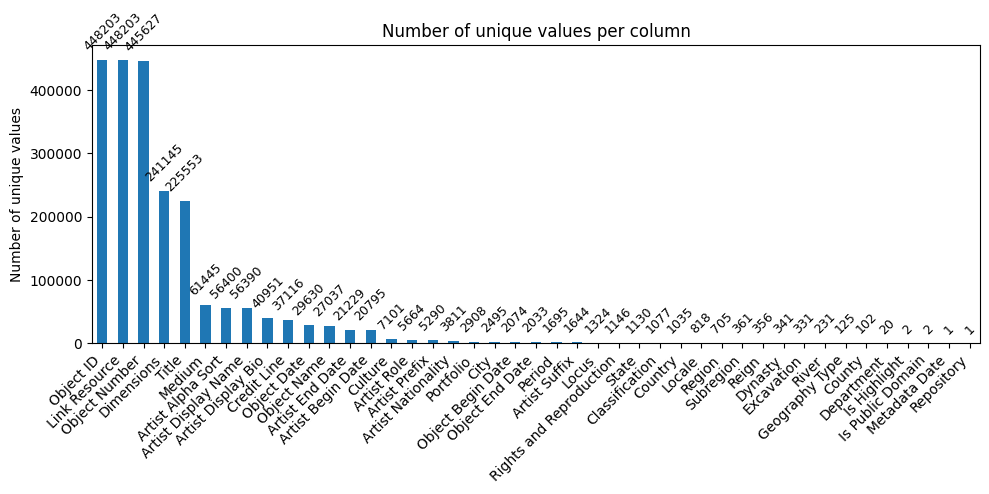

In [8]:
unique_counts = df.nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
ax = unique_counts.plot(kind="bar")

plt.ylabel("Number of unique values")
plt.title("Number of unique values per column")
plt.xticks(rotation=45, ha="right")

# add rotated value labels
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        rotation=45,          # 🔹 rotate numbers
        fontsize=9,
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

In [25]:
columns = [
    "Is Highlight", "Is Public Domain", "Department", "Title", "Culture",
    "Period", "Dynasty", "Reign", "Portfolio", "Artist Role",
    "Artist Prefix", "Artist Display Name", "Artist Display Bio",
    "Artist Suffix", "Artist Alpha Sort", "Artist Nationality",
    "Artist Begin Date", "Artist End Date", "Object Date",
    "Object Begin Date", "Object End Date", "Medium", "Dimensions",
    "Credit Line", "Geography Type", "City", "State", "County",
    "Country", "Region", "Subregion", "Locale", "Locus",
    "Excavation", "River", "Classification",
    "Rights and Reproduction"
]


In [26]:
# create a color palette (one color per column)
colors = plt.cm.tab20(np.linspace(0, 1, len(columns)))

Plotting column: Is Highlight


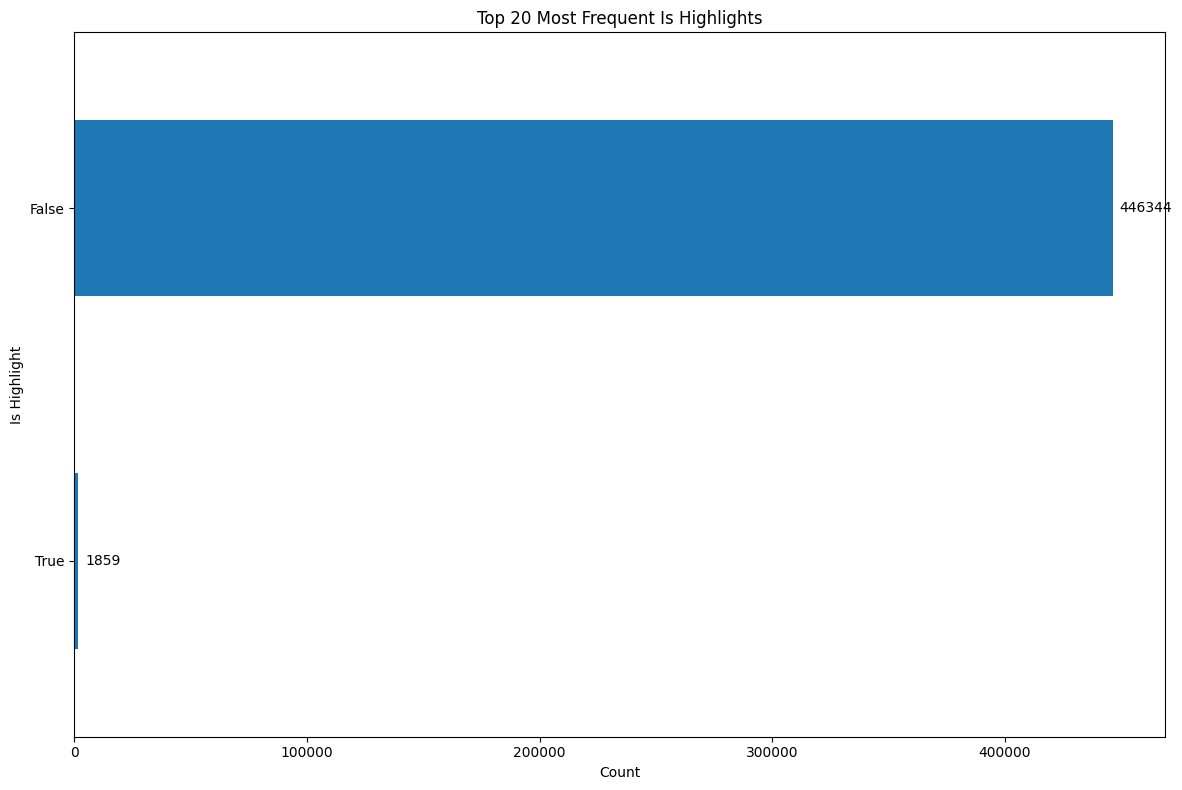

Plotting column: Is Public Domain


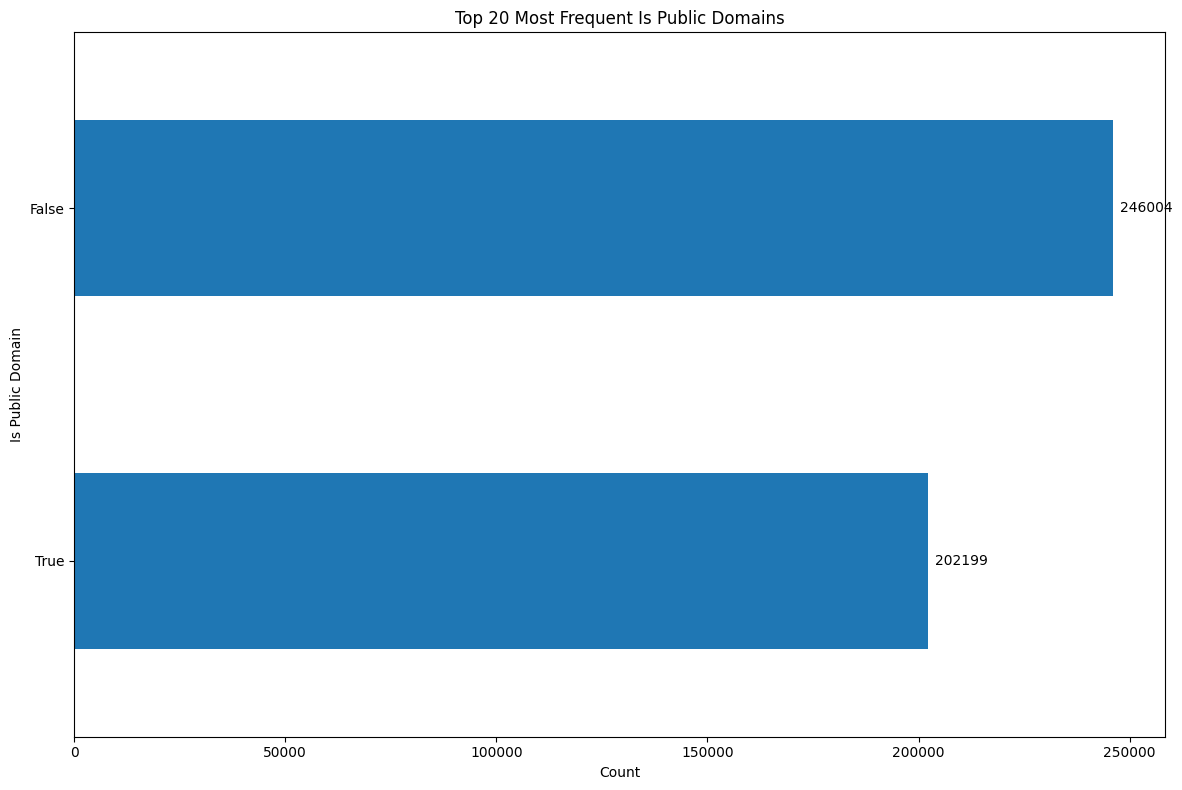

Plotting column: Department


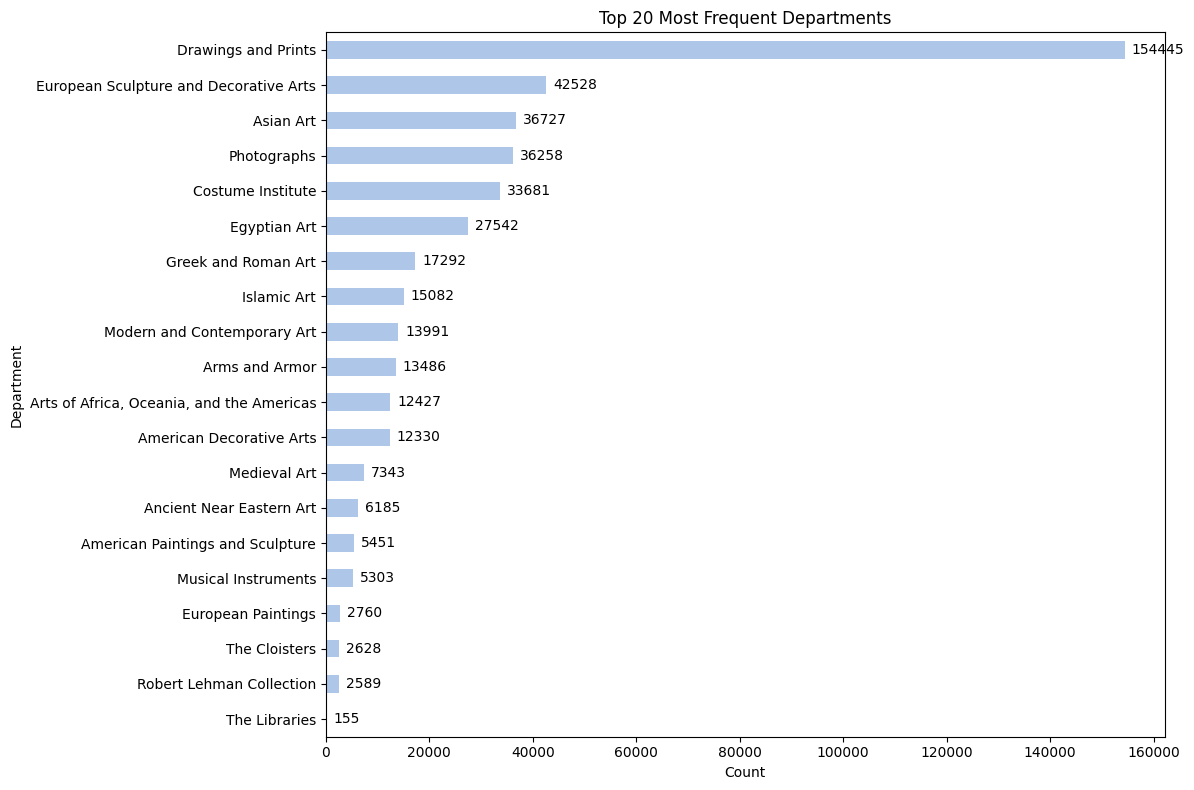

Plotting column: Title


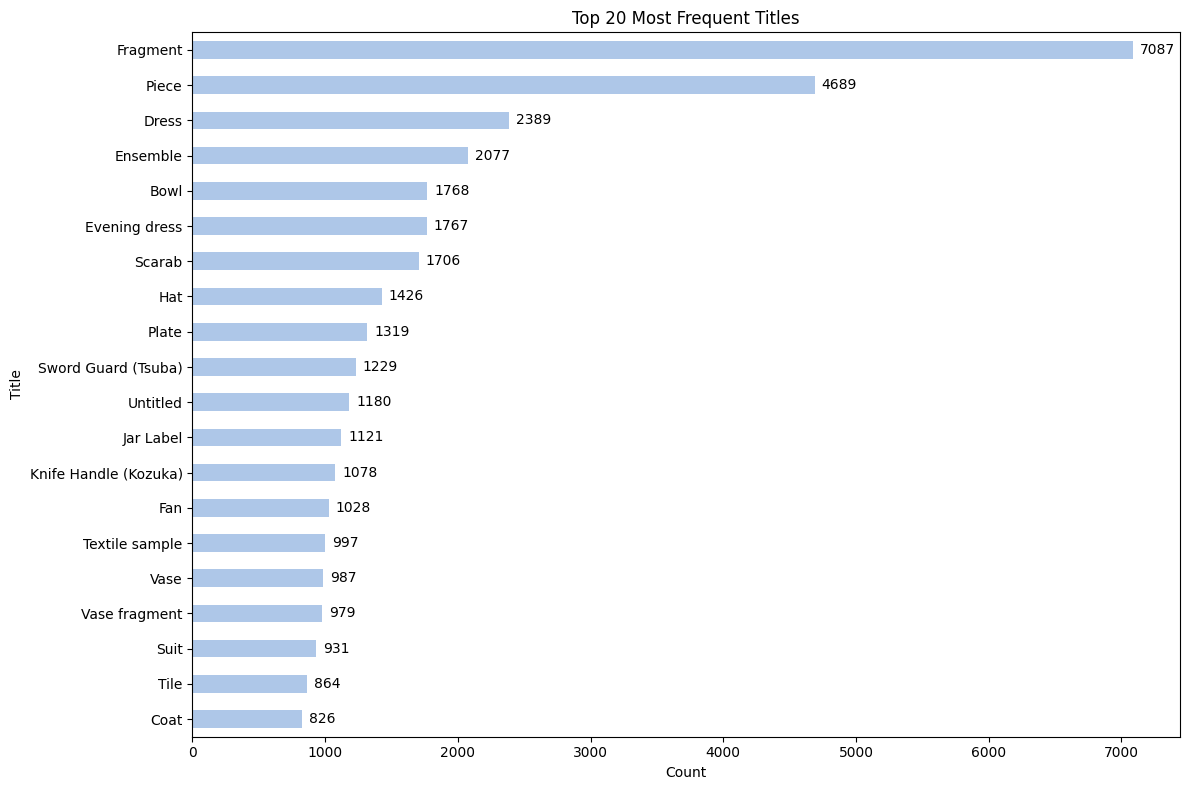

Plotting column: Culture


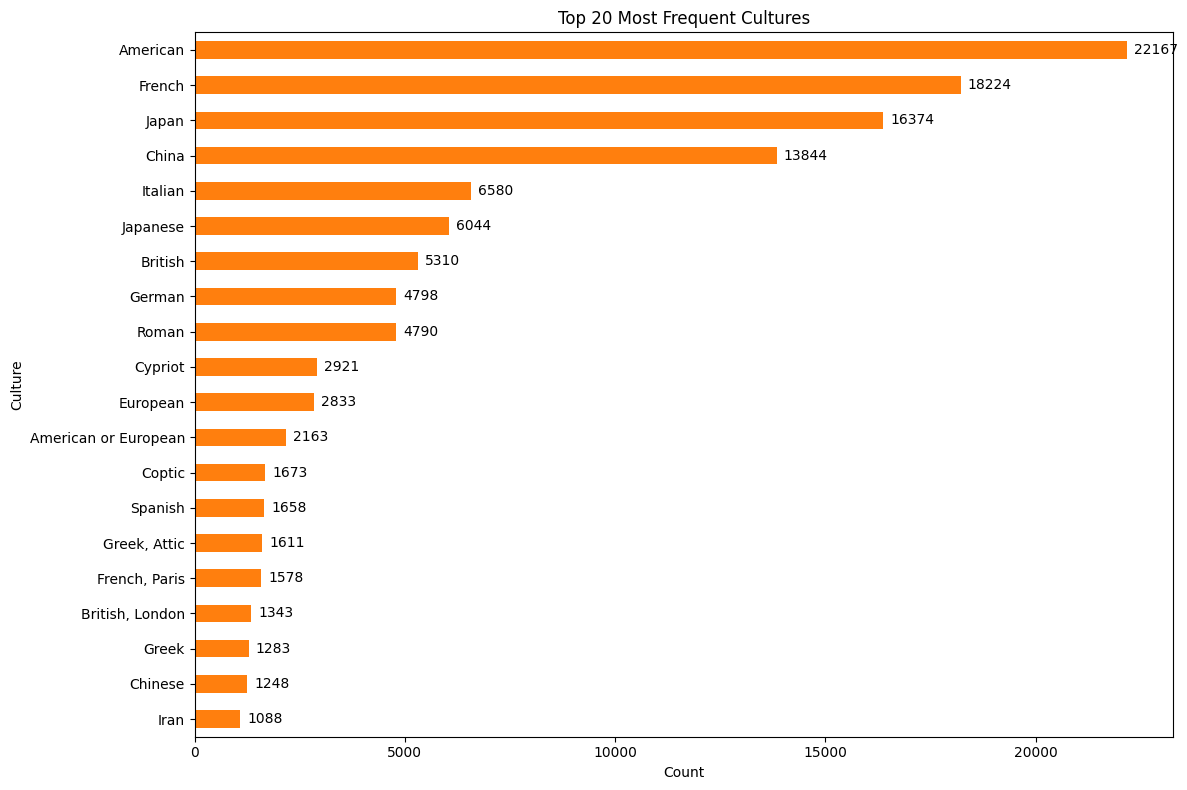

Plotting column: Period


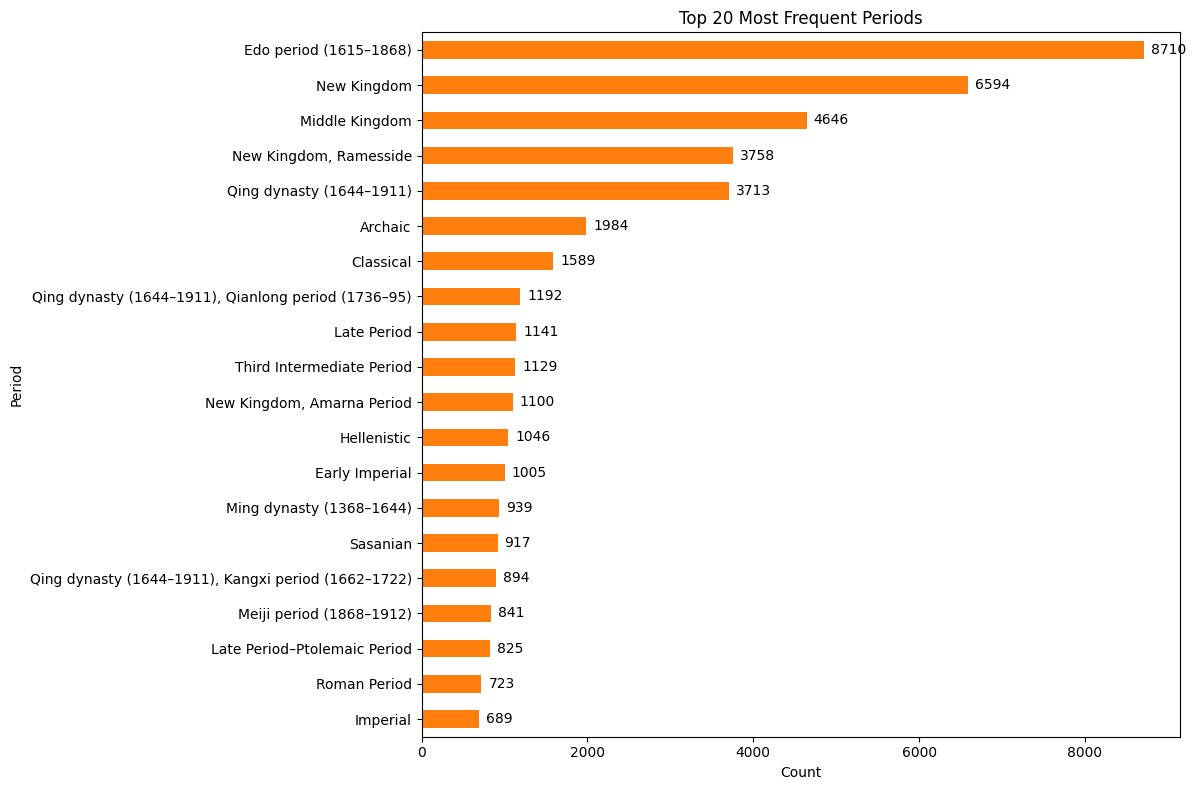

Plotting column: Dynasty


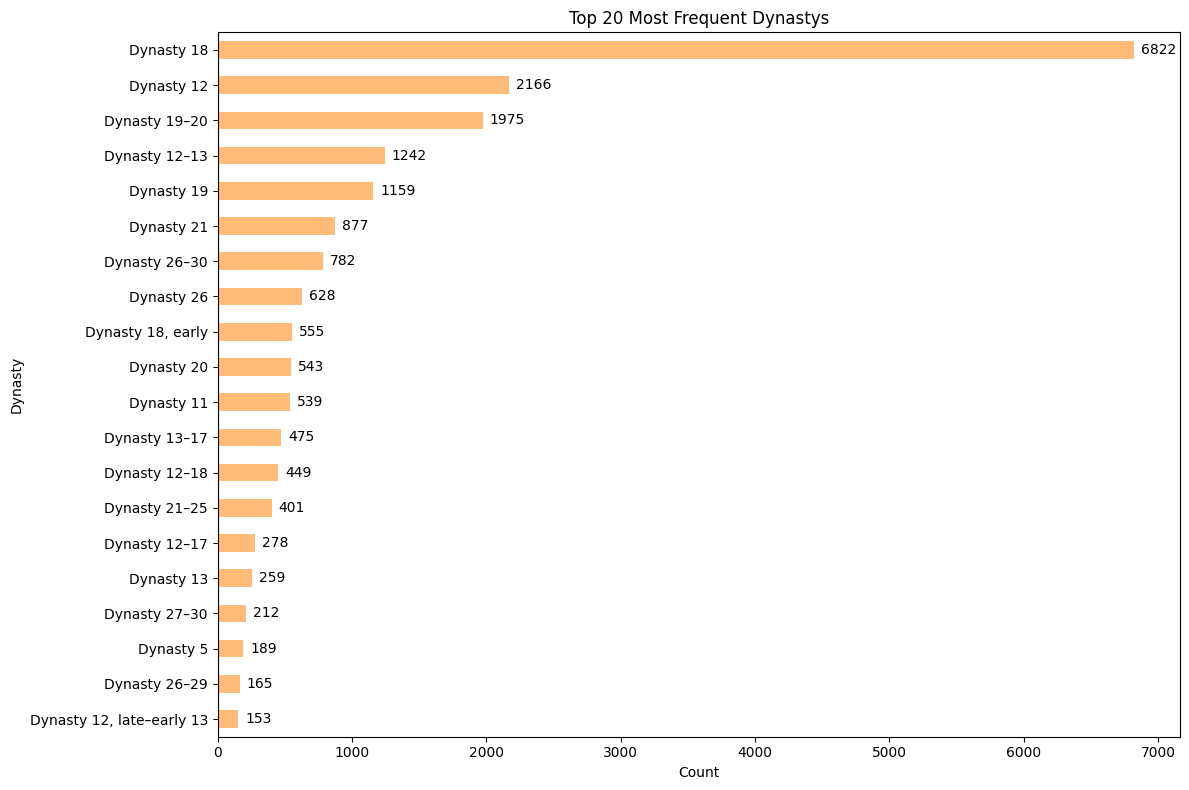

Plotting column: Reign


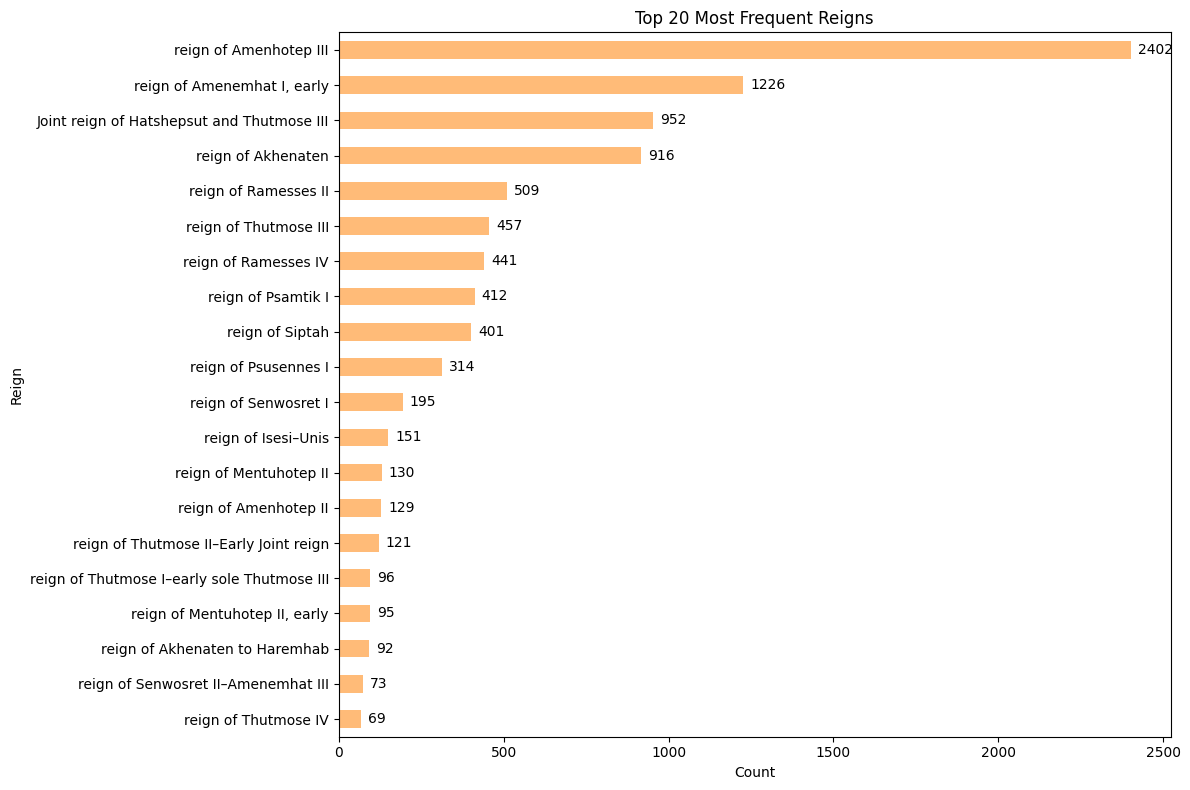

Plotting column: Portfolio


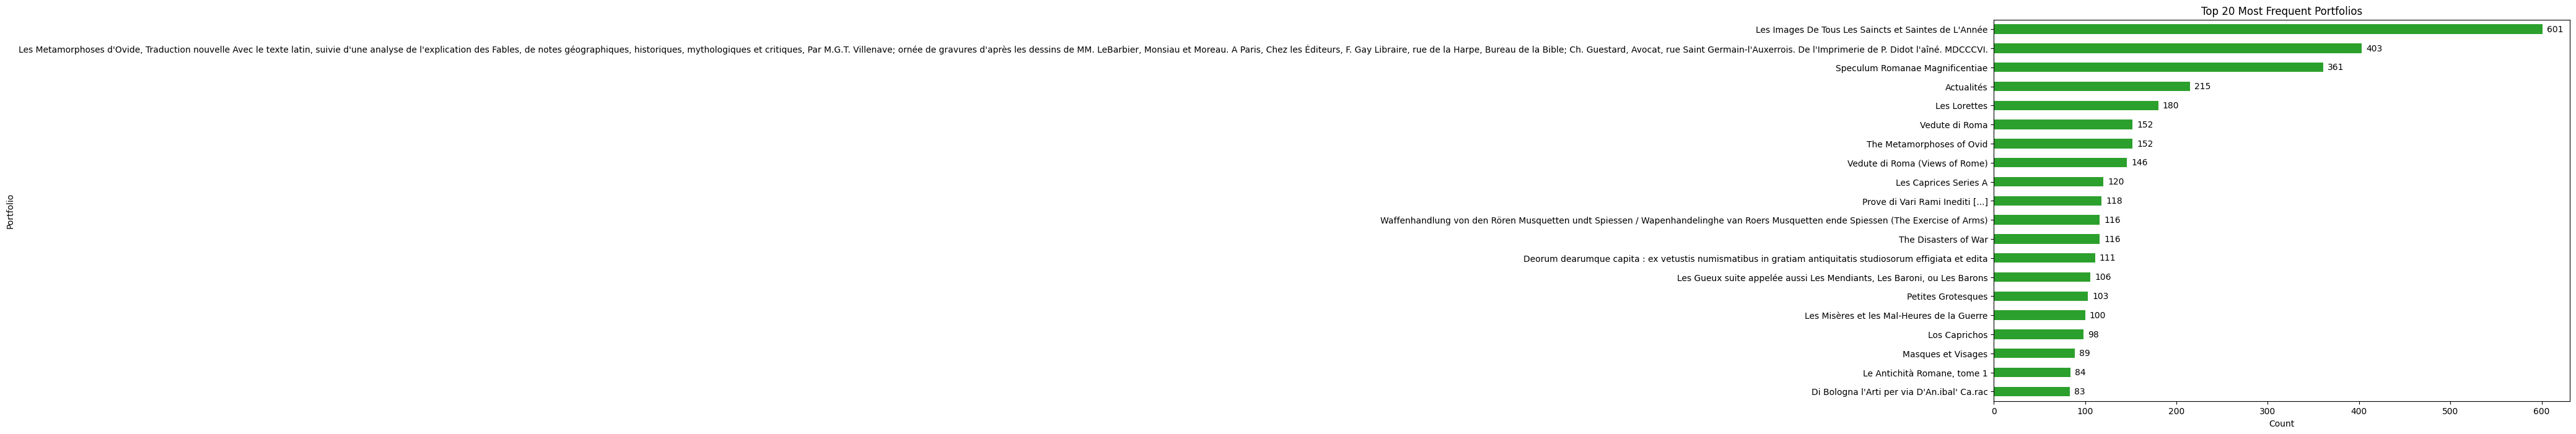

Plotting column: Artist Role


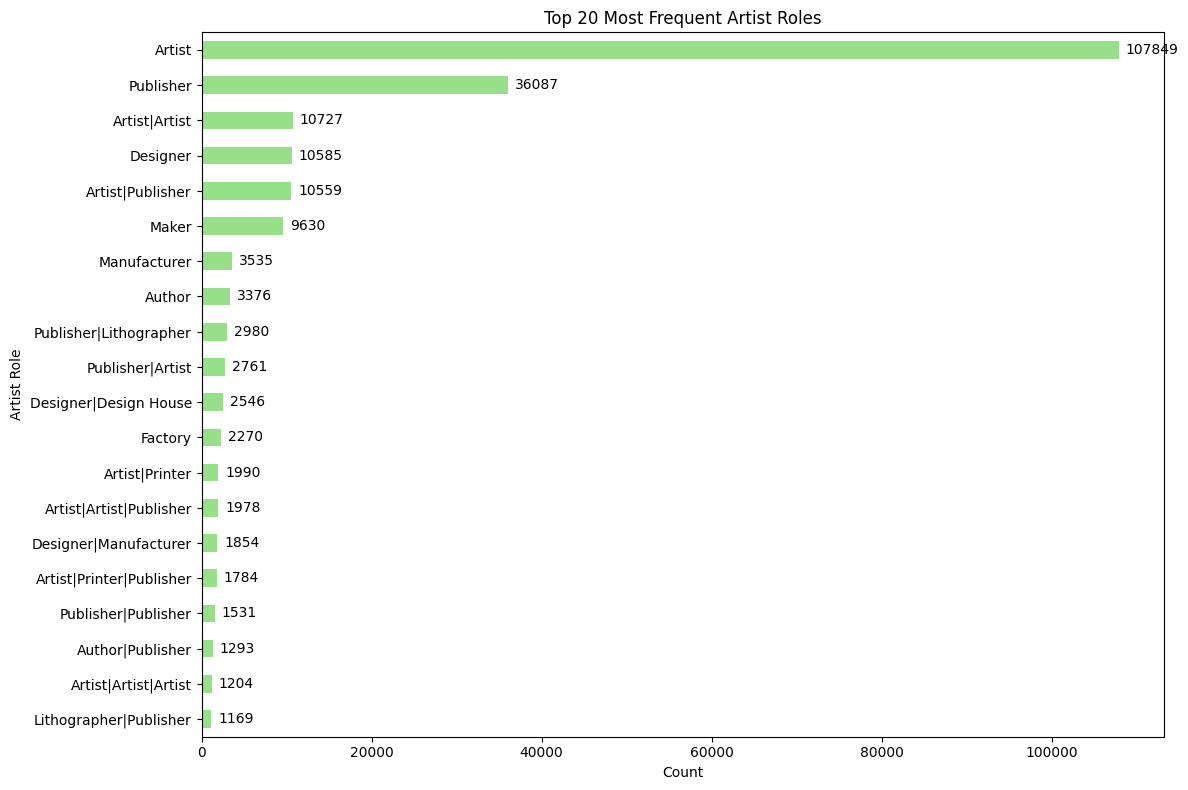

Plotting column: Artist Prefix


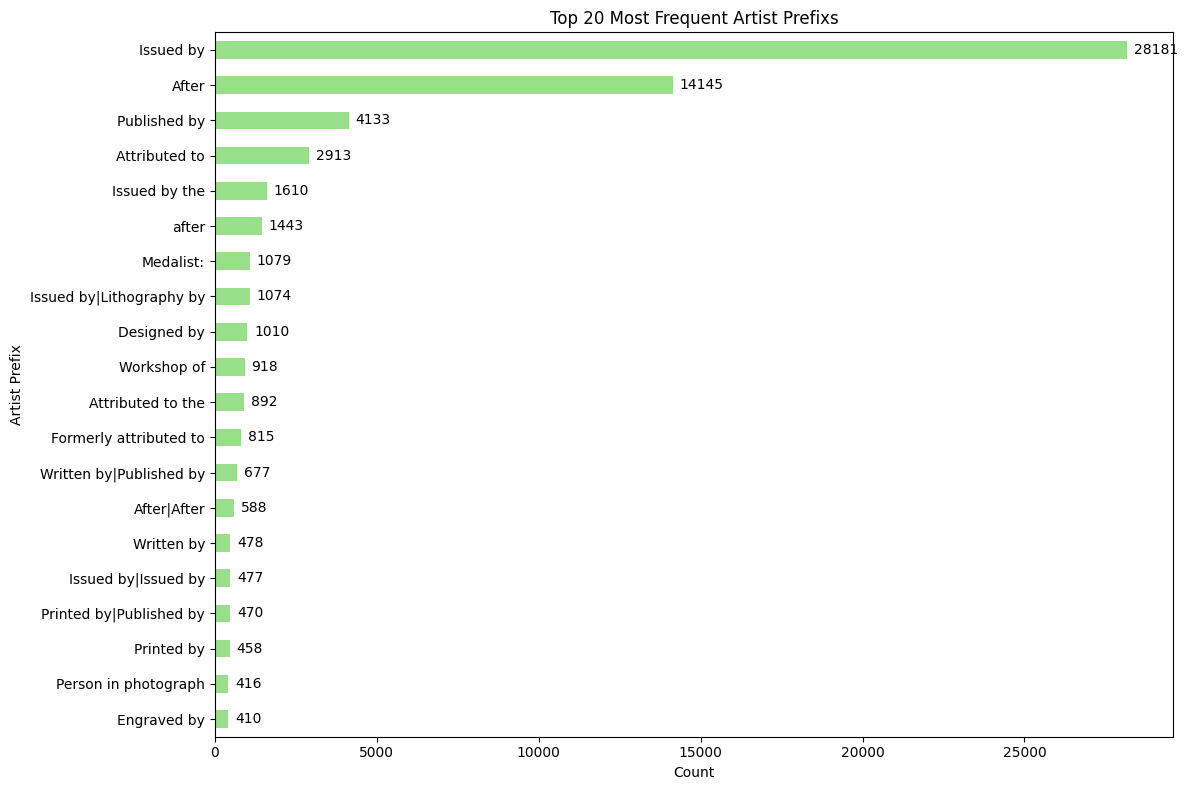

Plotting column: Artist Display Name


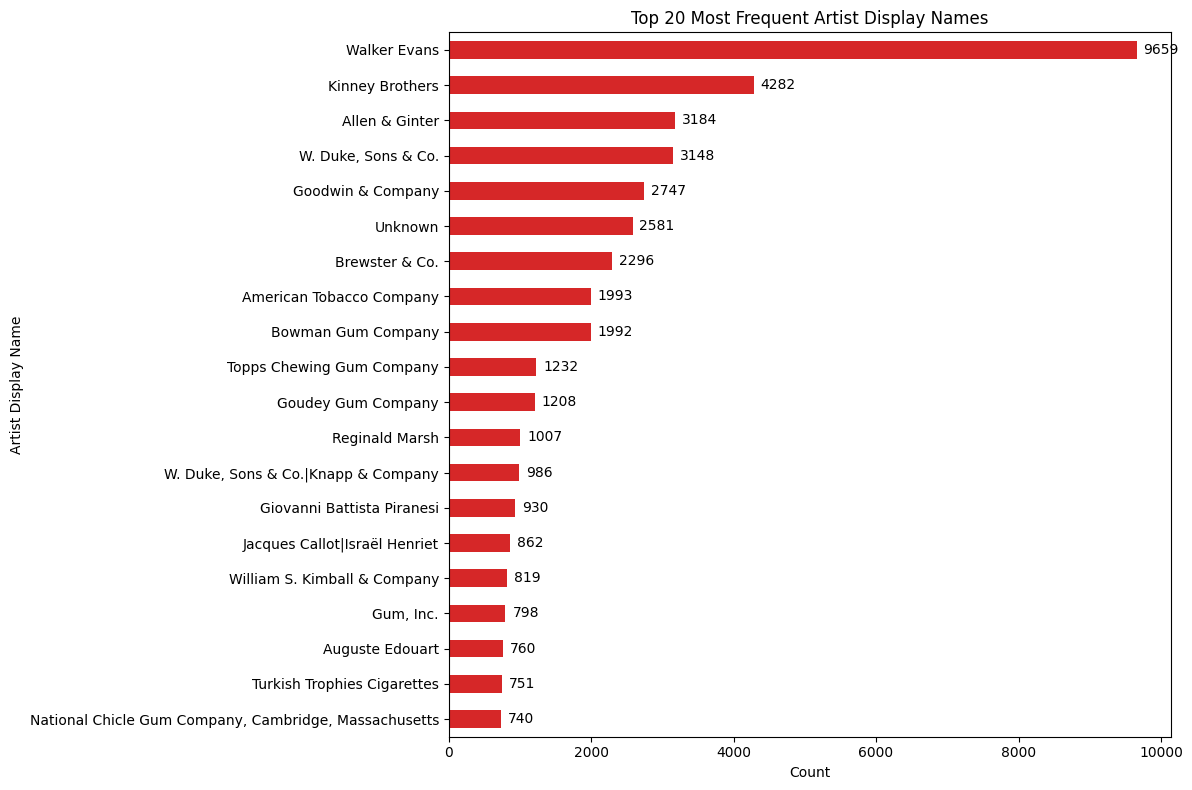

Plotting column: Artist Display Bio


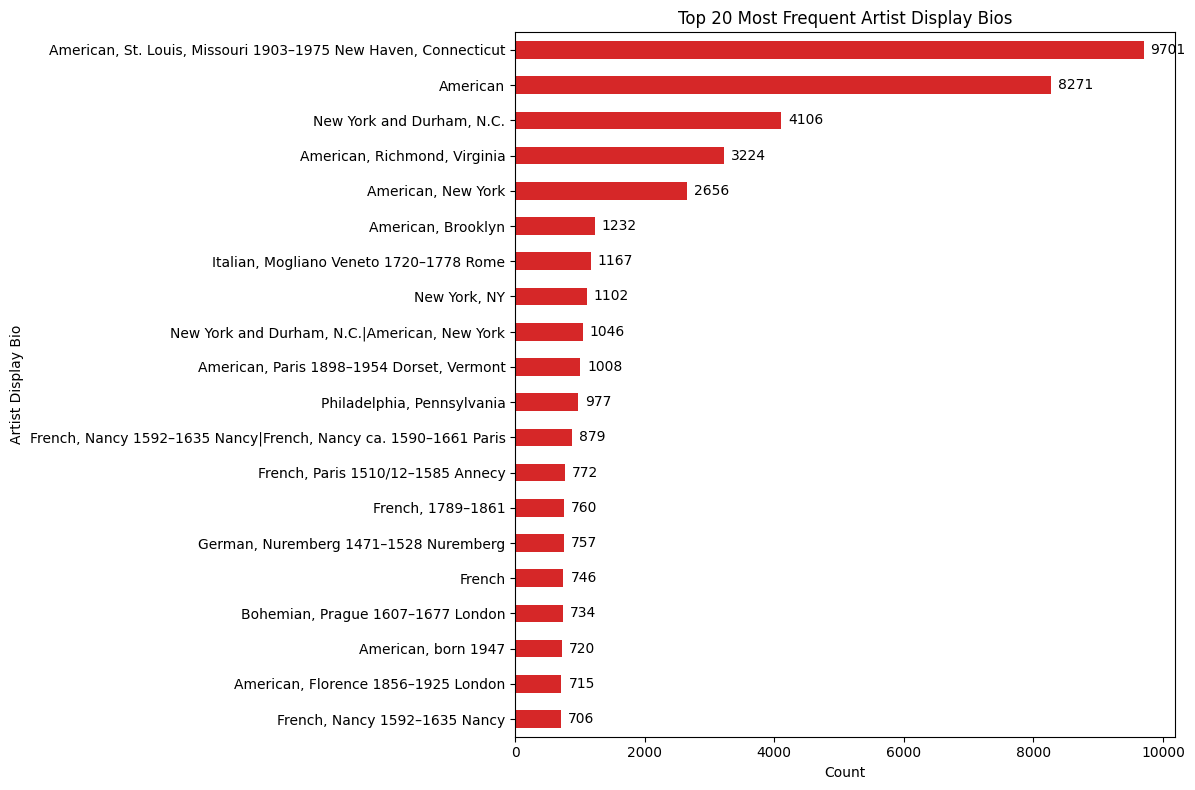

Plotting column: Artist Suffix


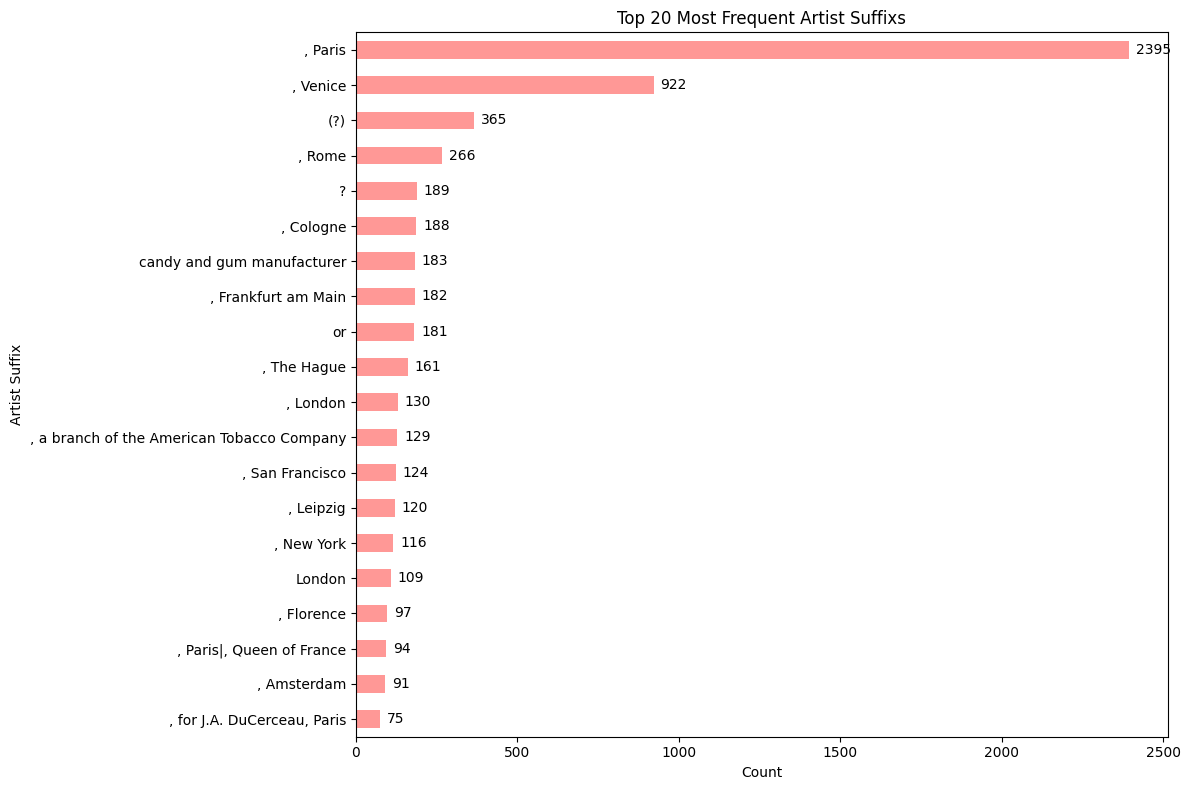

Plotting column: Artist Alpha Sort


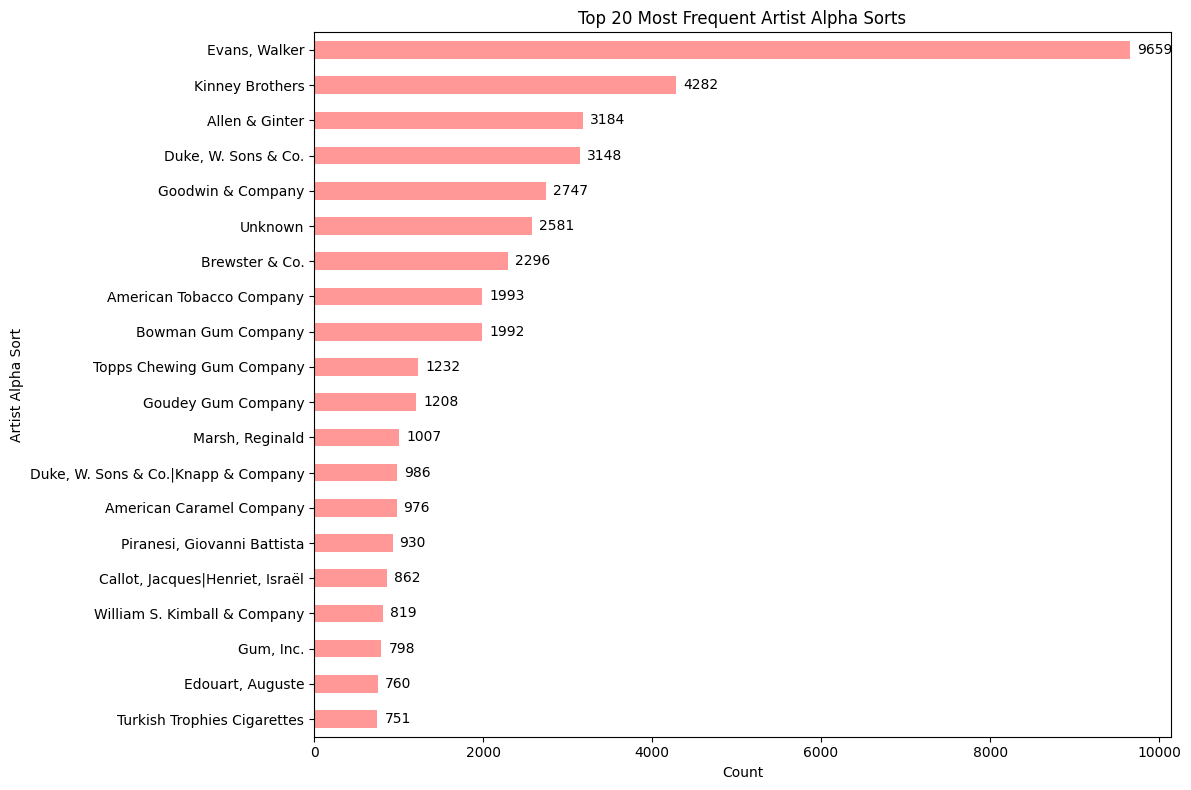

Plotting column: Artist Nationality


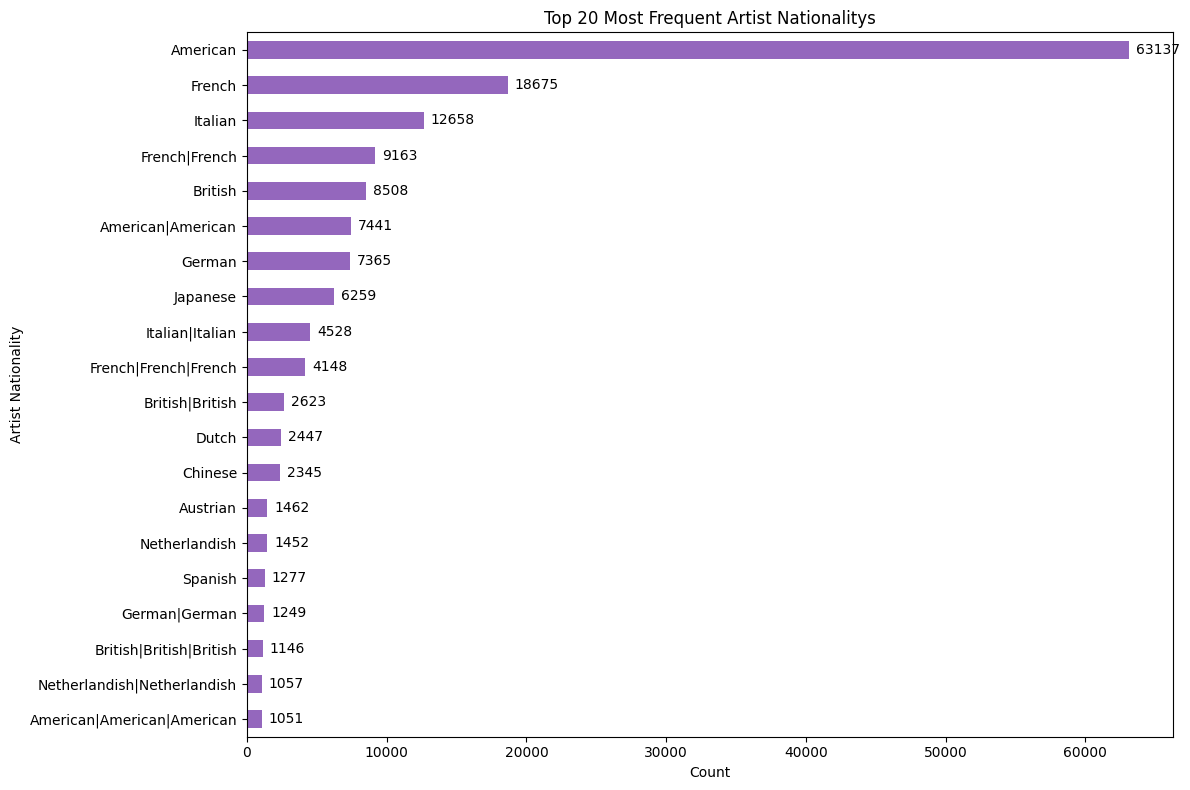

Plotting column: Artist Begin Date


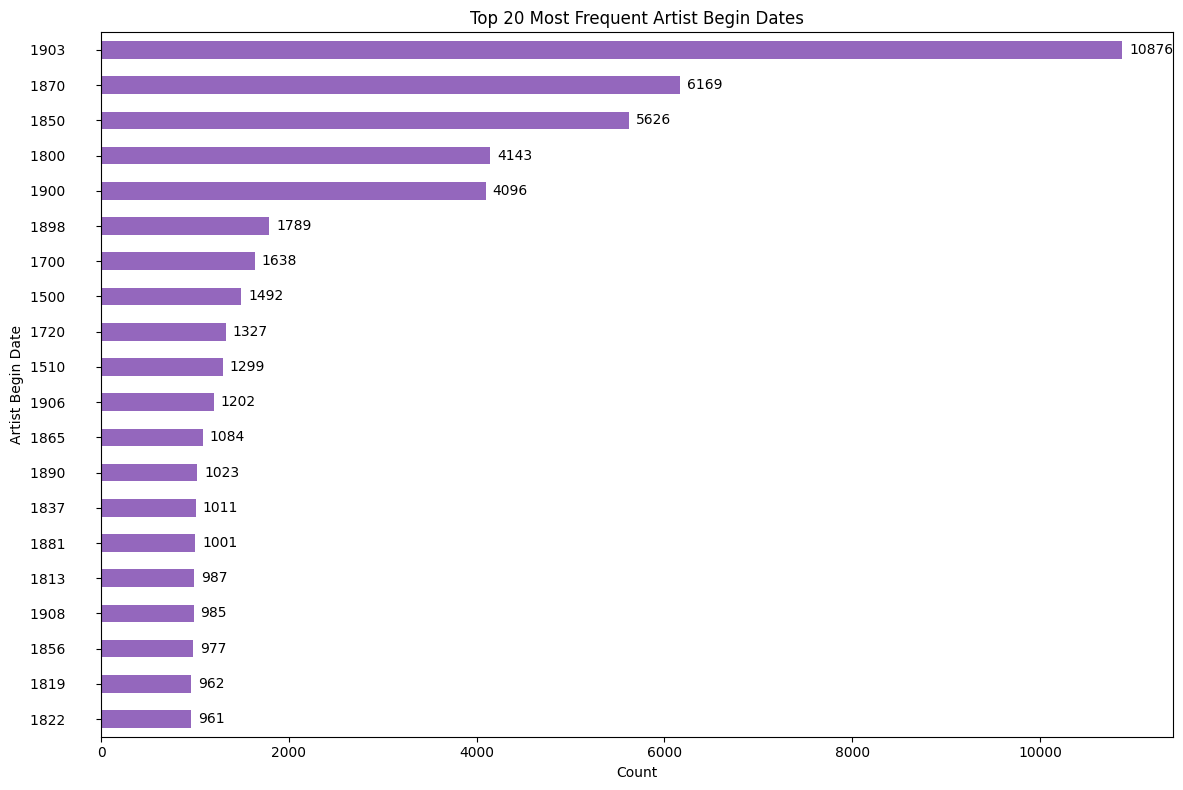

Plotting column: Artist End Date


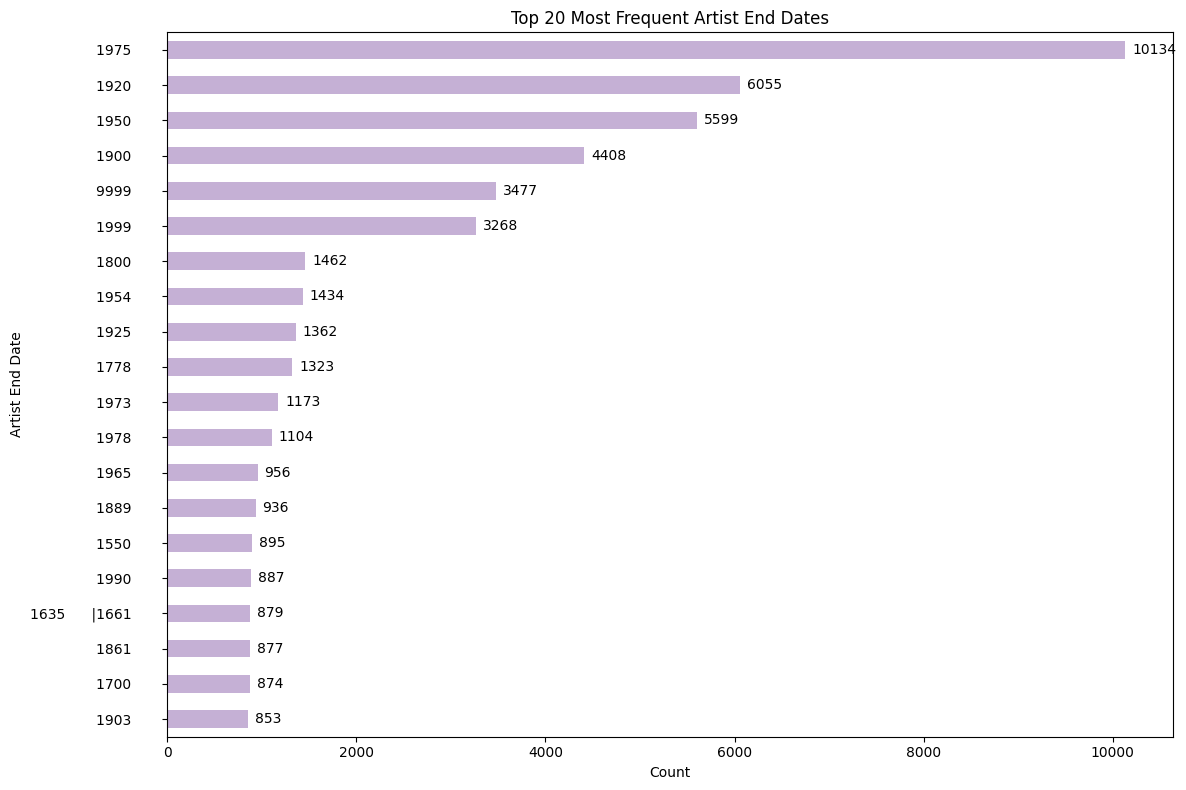

Plotting column: Object Date


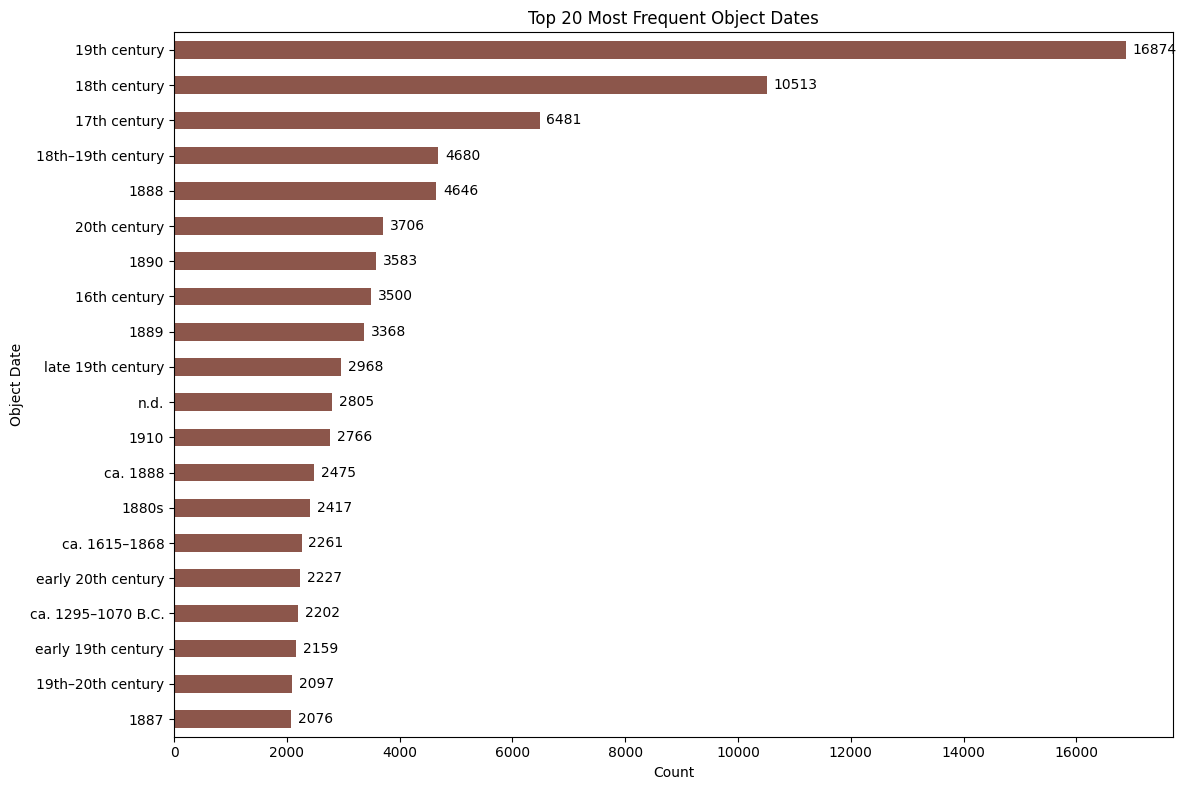

Plotting column: Object Begin Date


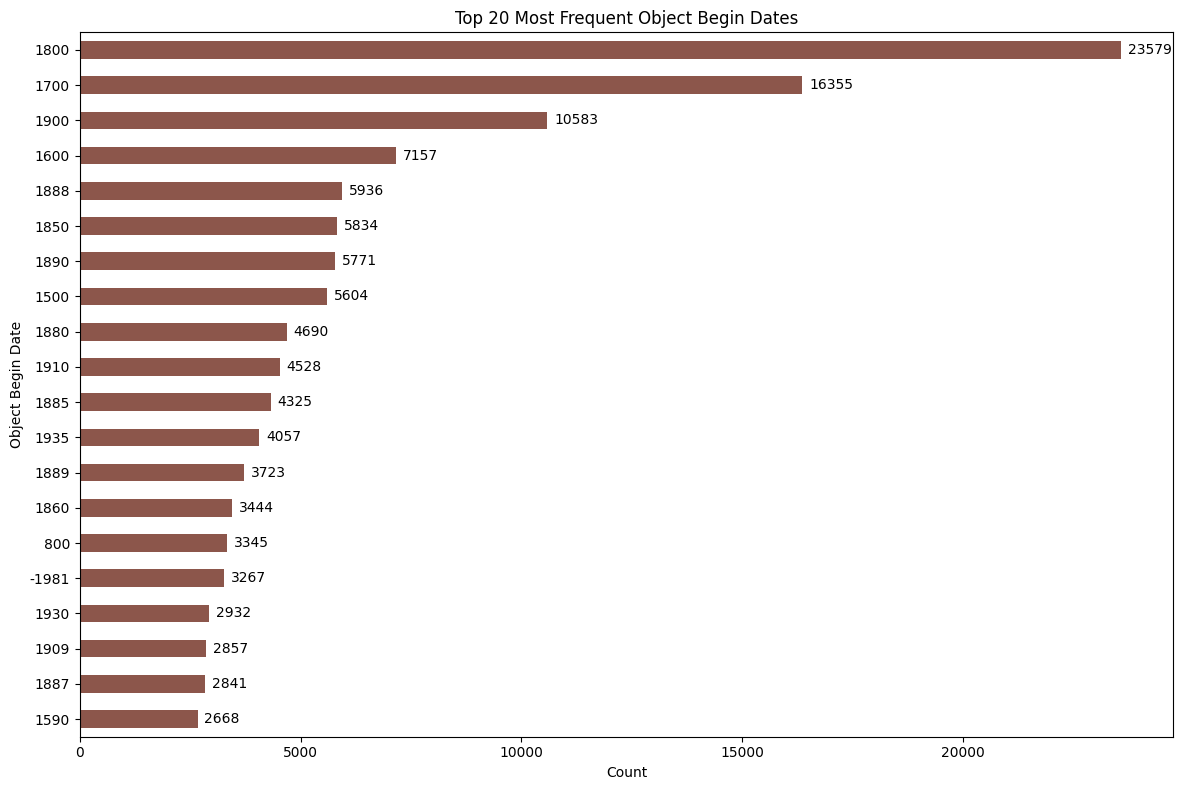

Plotting column: Object End Date


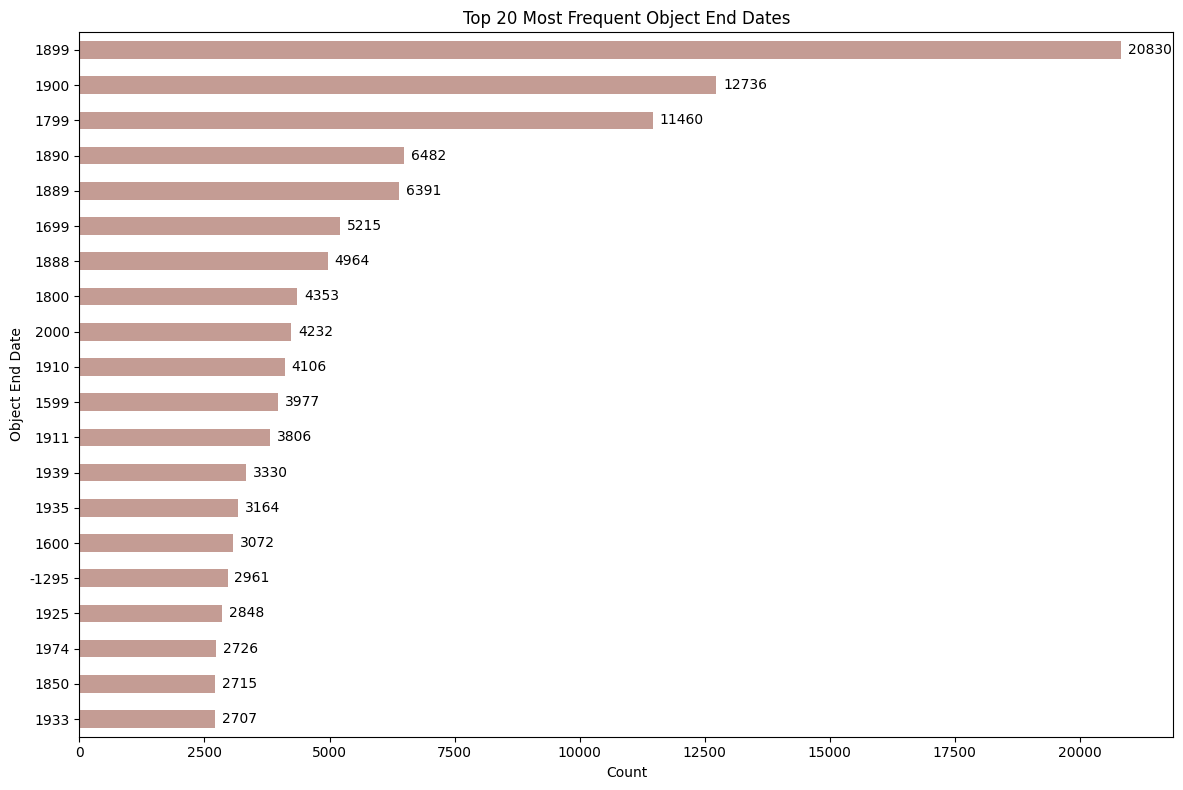

Plotting column: Medium


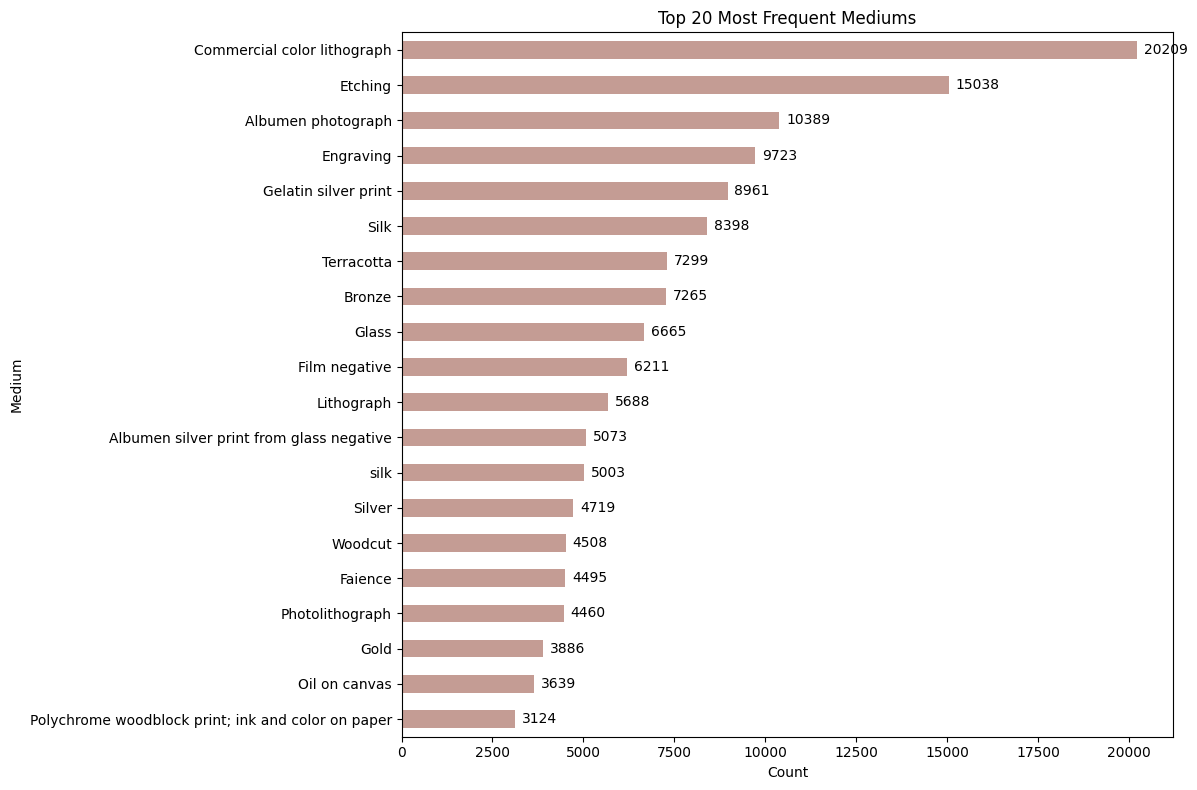

Plotting column: Dimensions


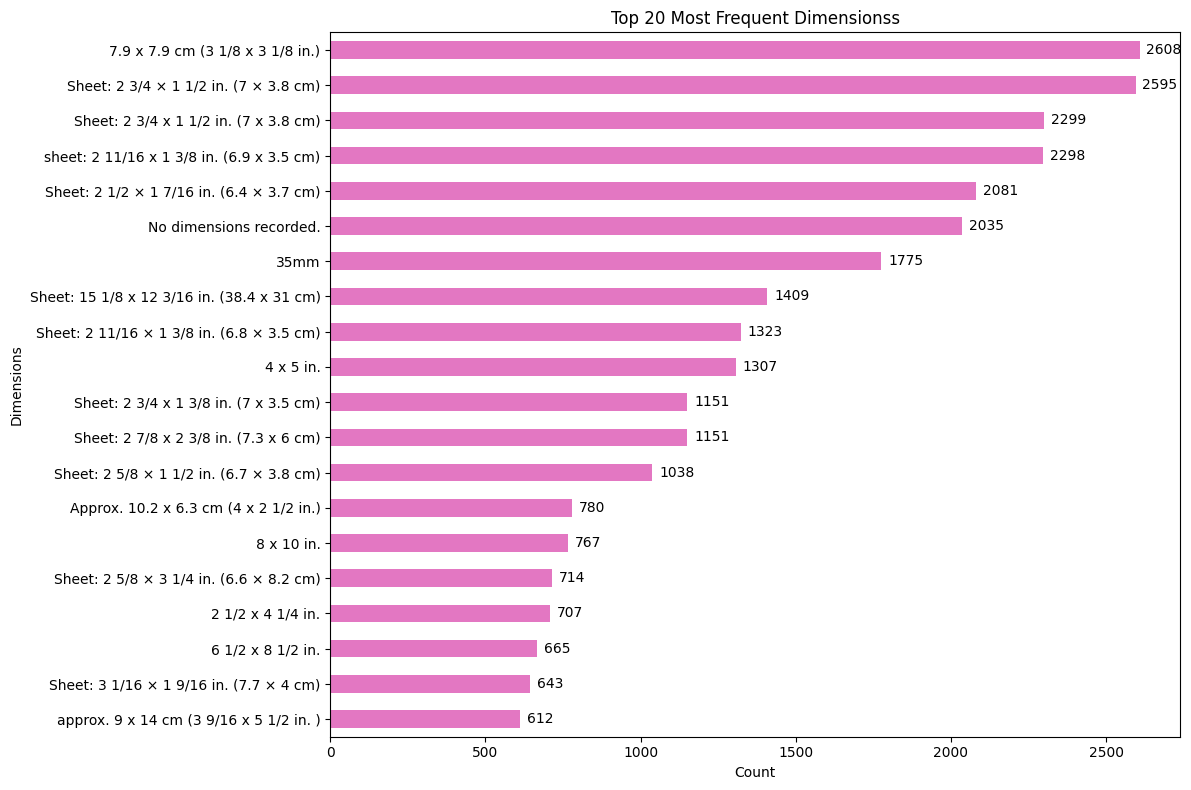

Plotting column: Credit Line


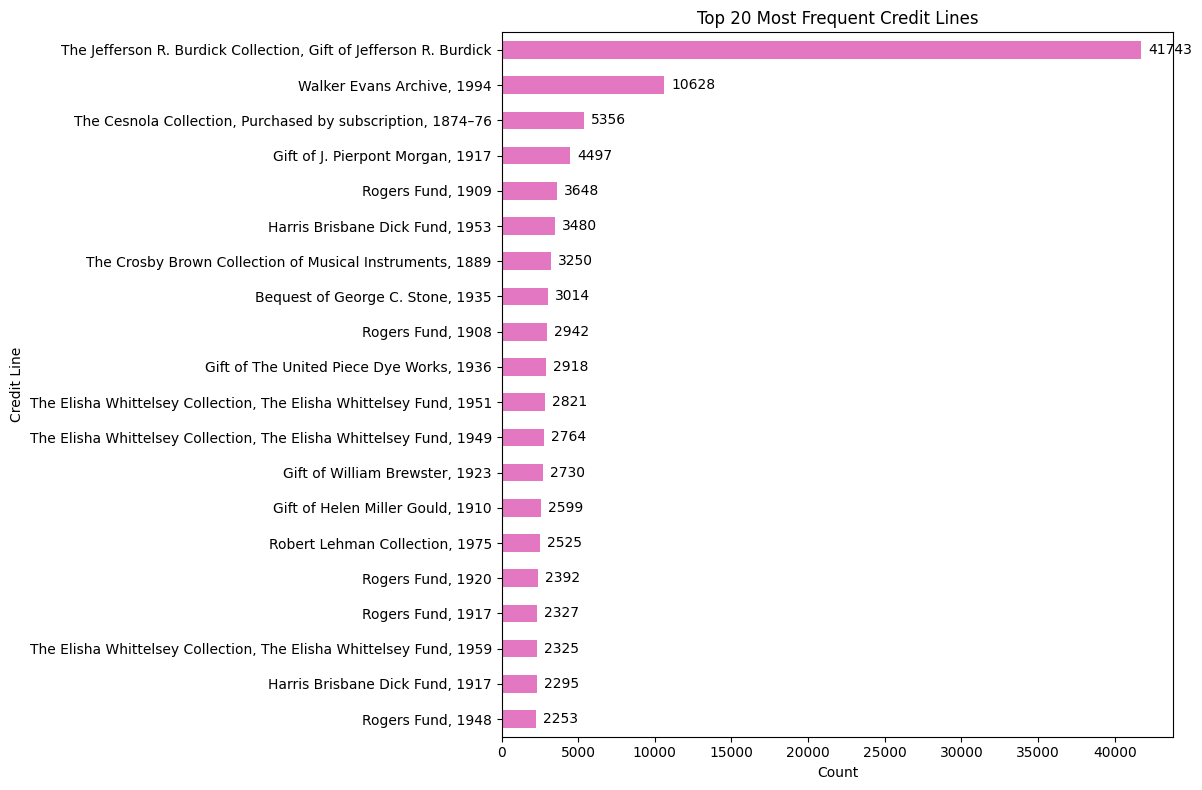

Plotting column: Geography Type


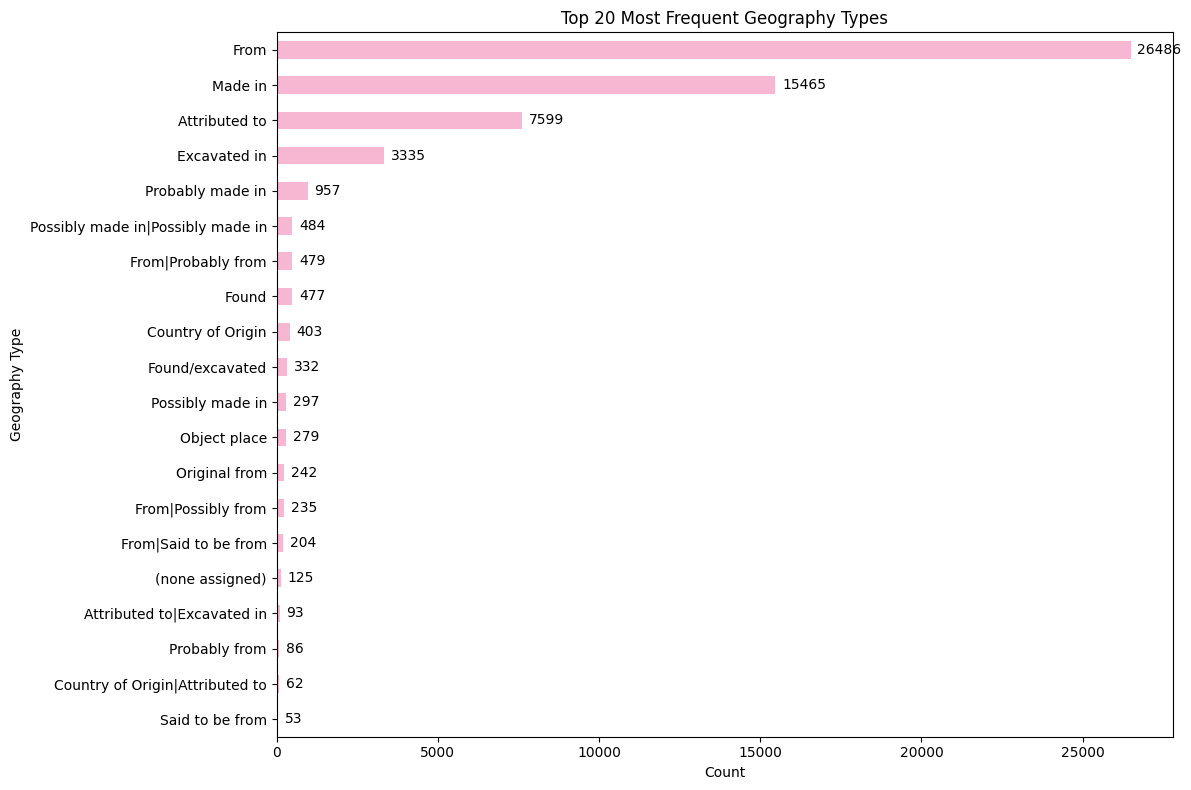

Plotting column: City


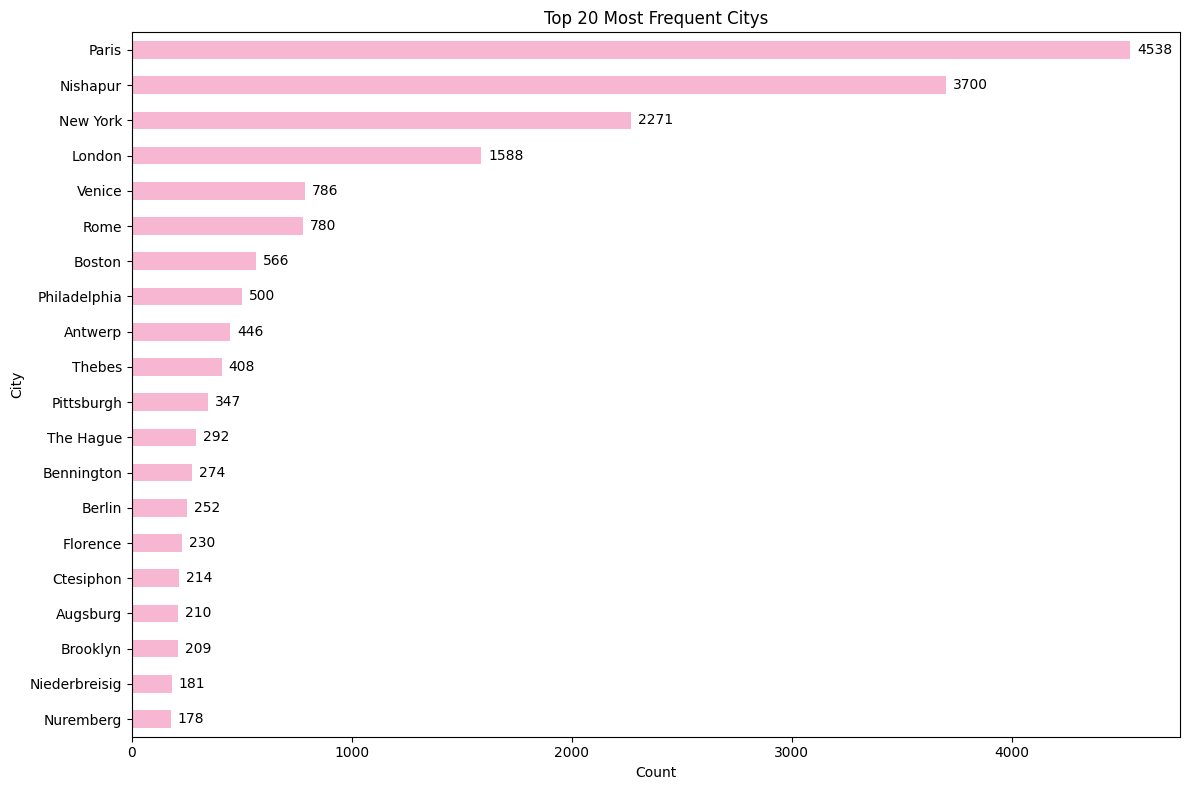

Plotting column: State


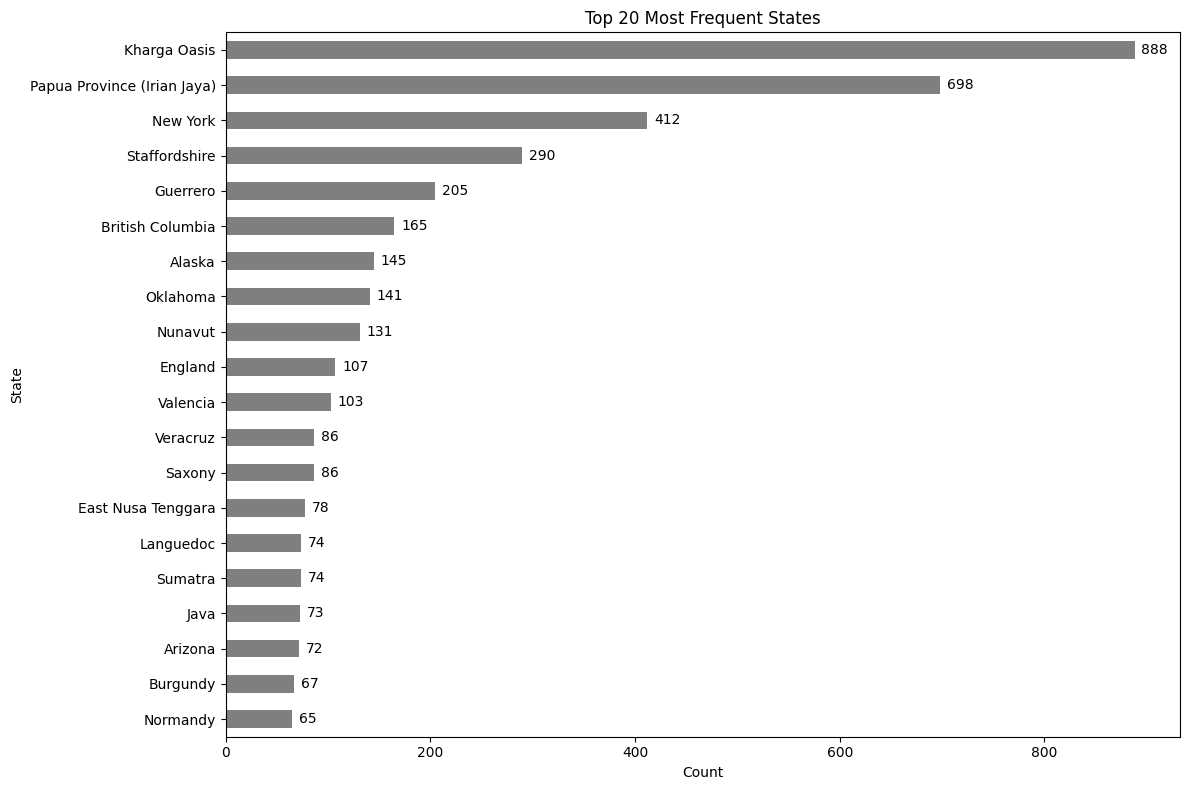

Plotting column: County


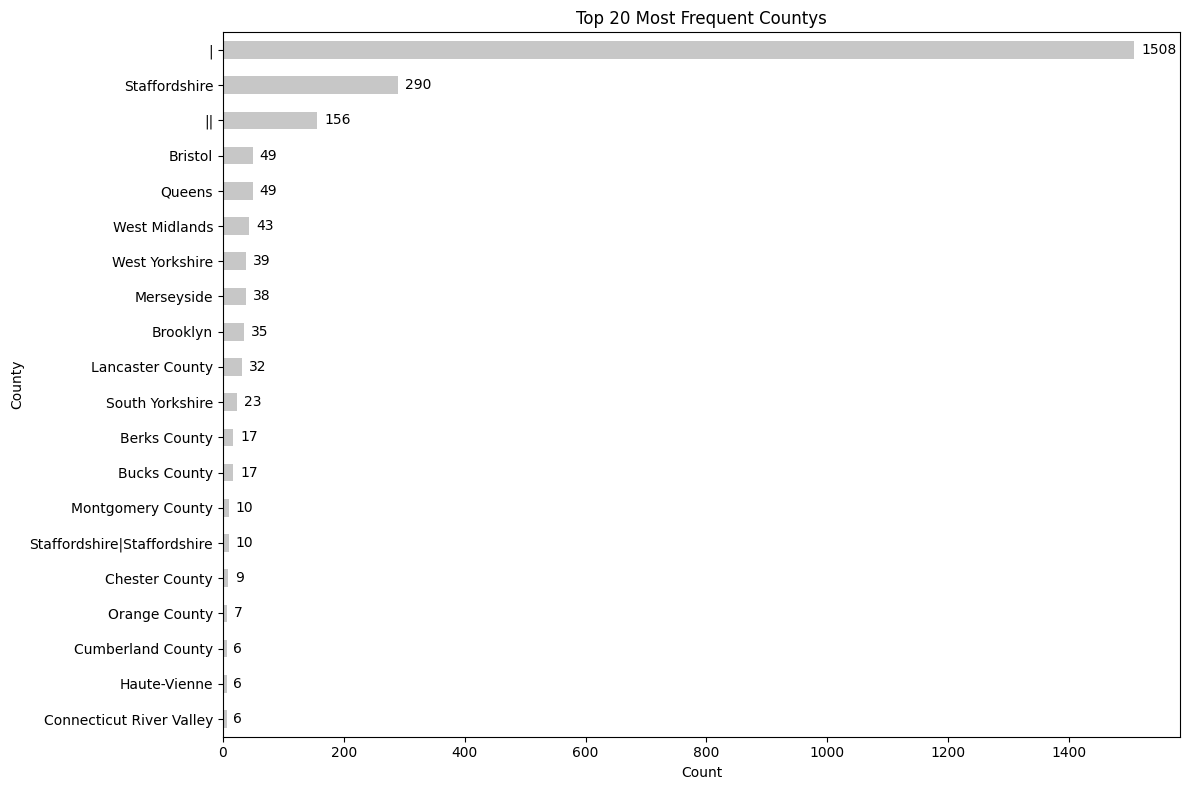

Plotting column: Country


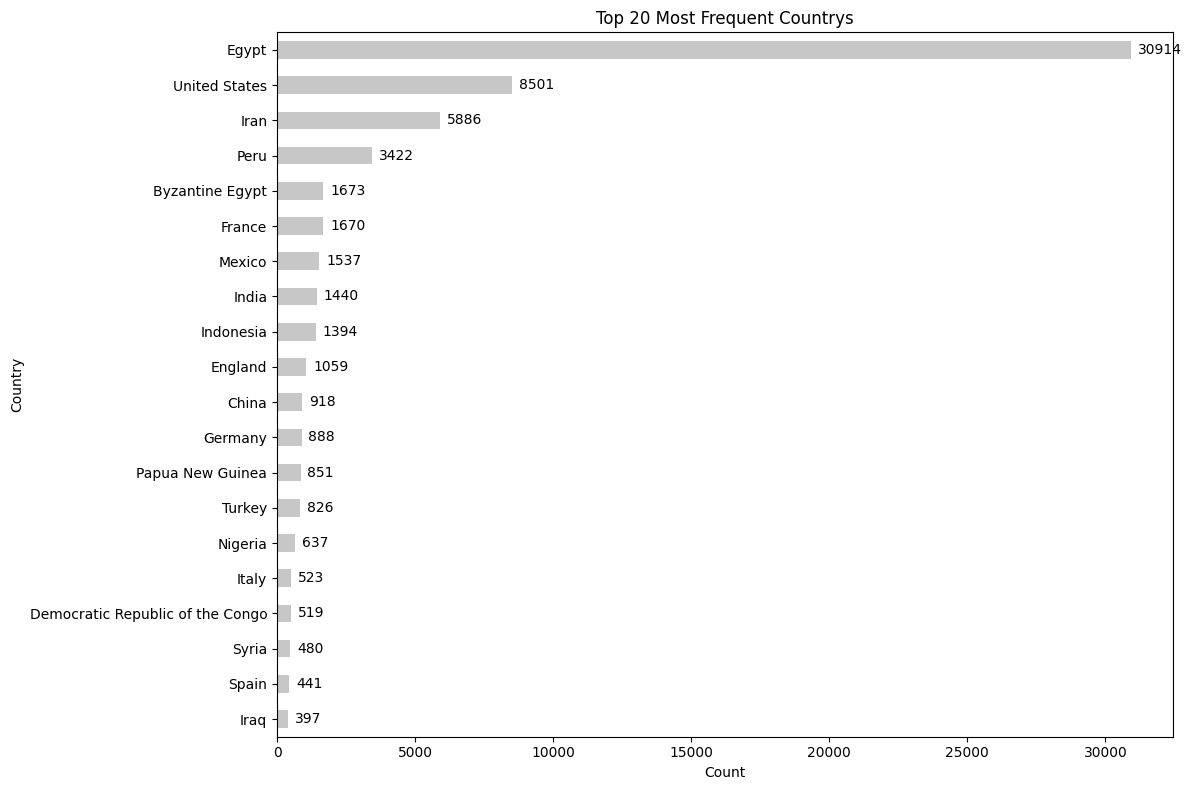

Plotting column: Region


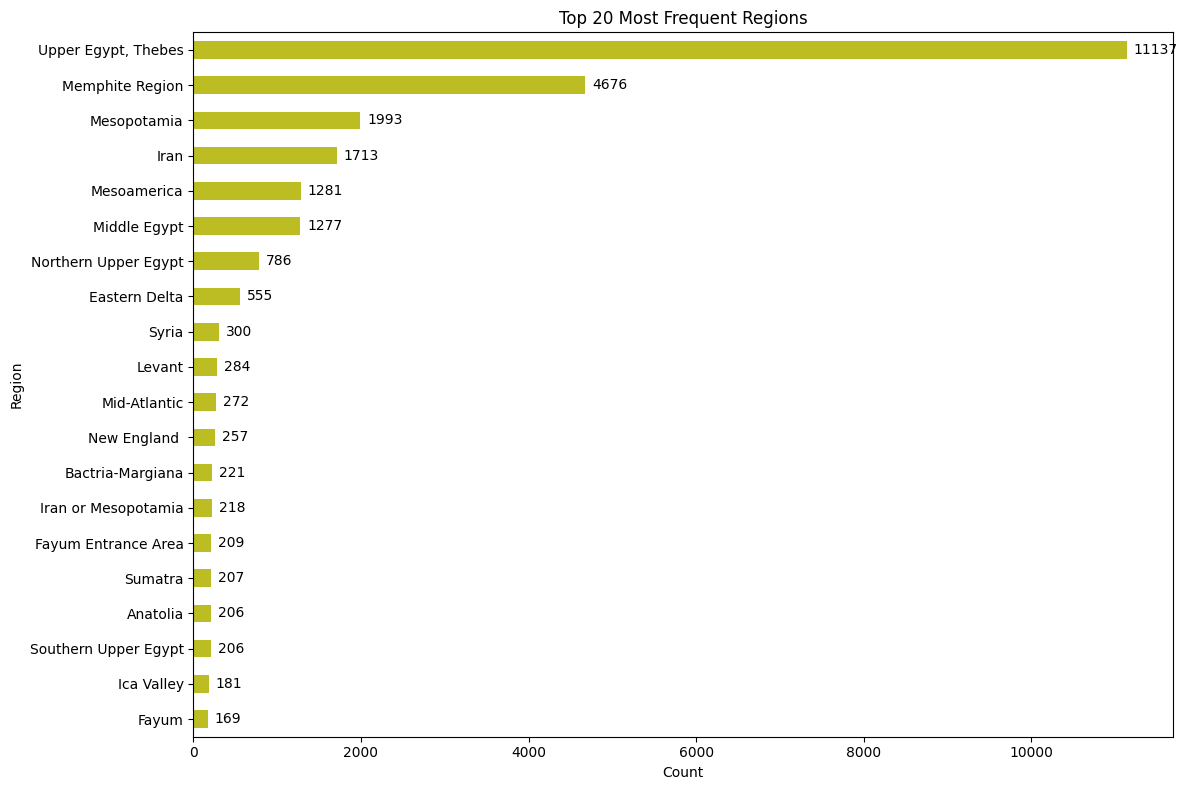

Plotting column: Subregion


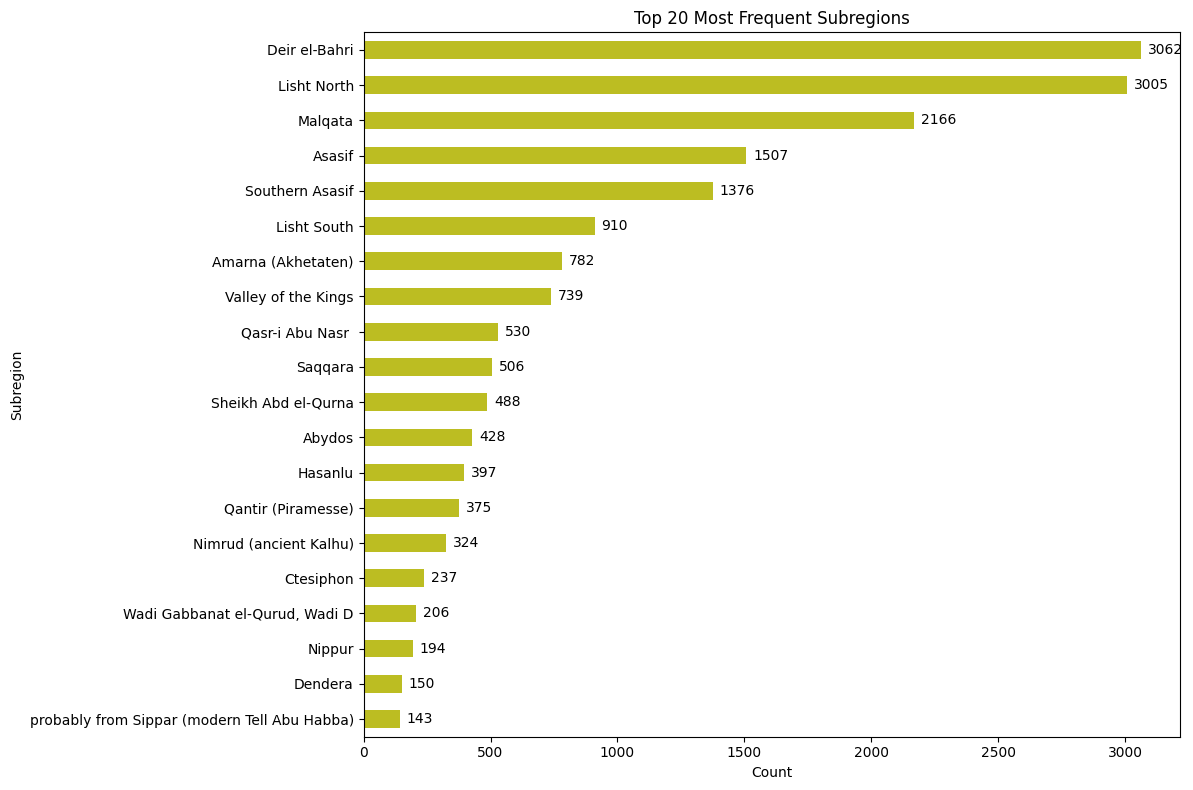

Plotting column: Locale


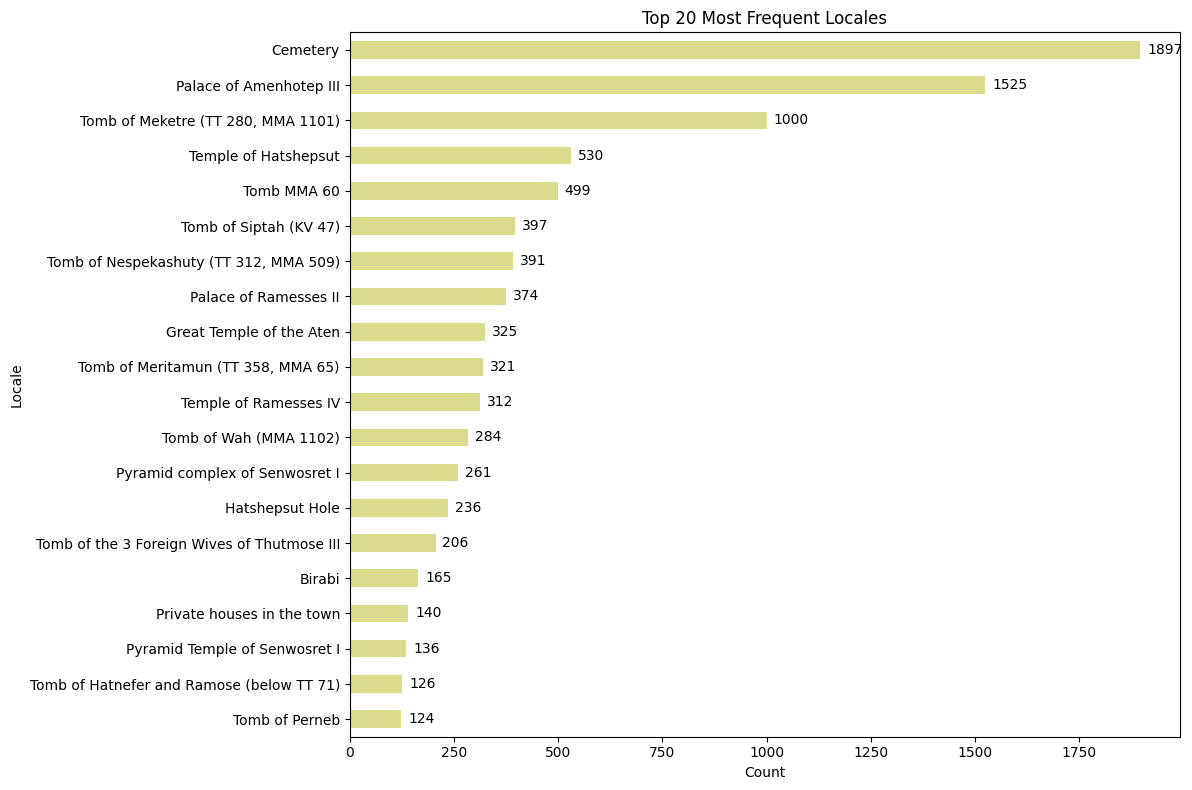

Plotting column: Locus


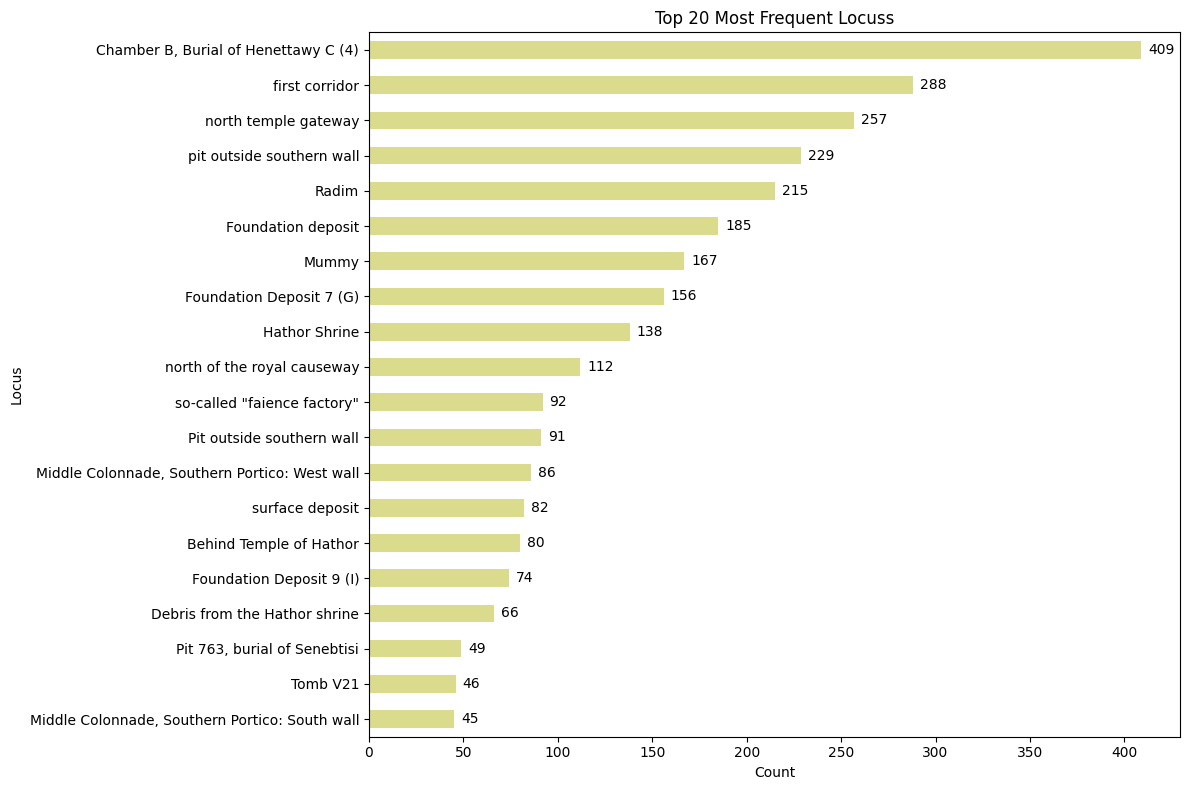

Plotting column: Excavation


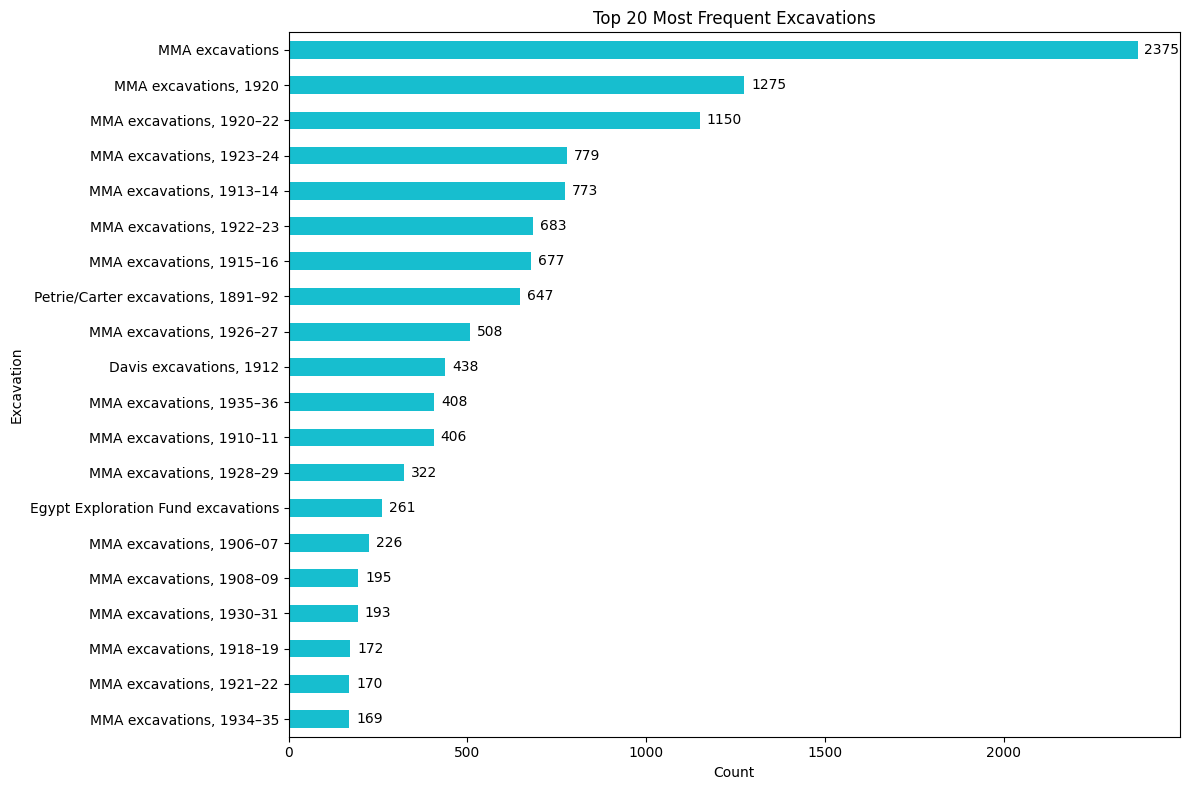

Plotting column: River


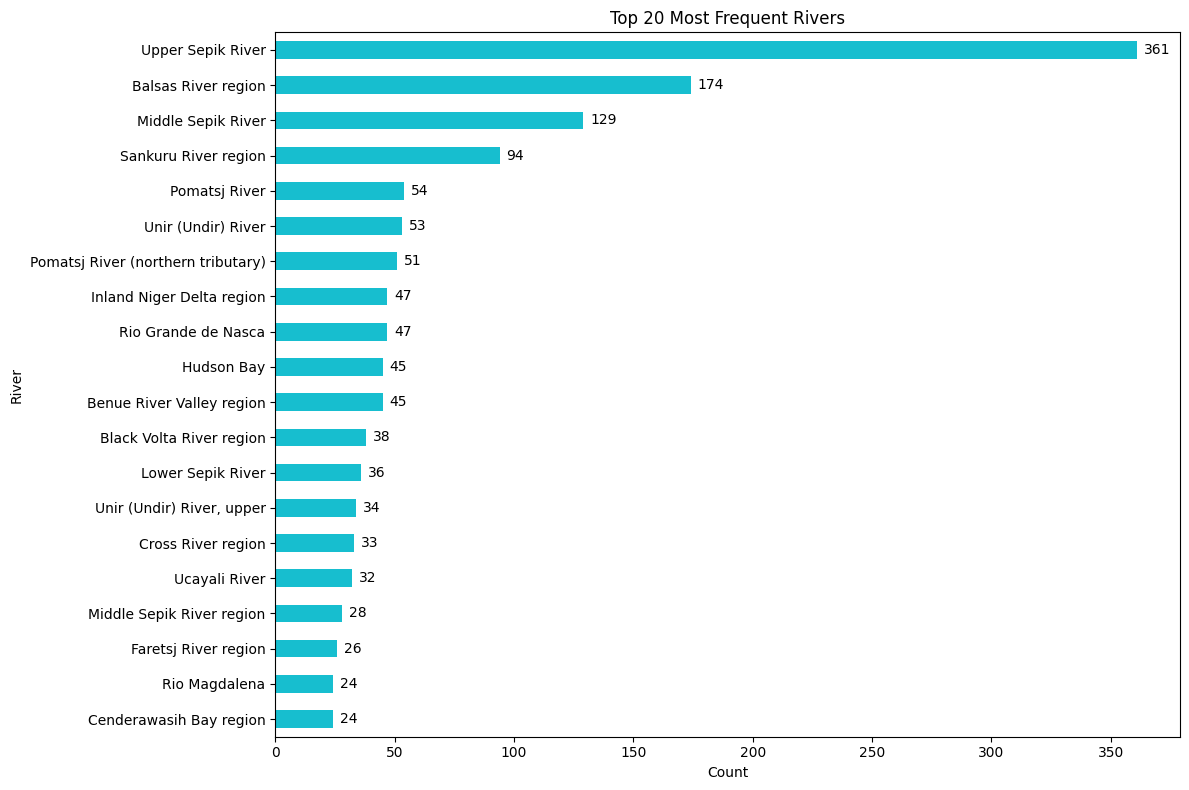

Plotting column: Classification


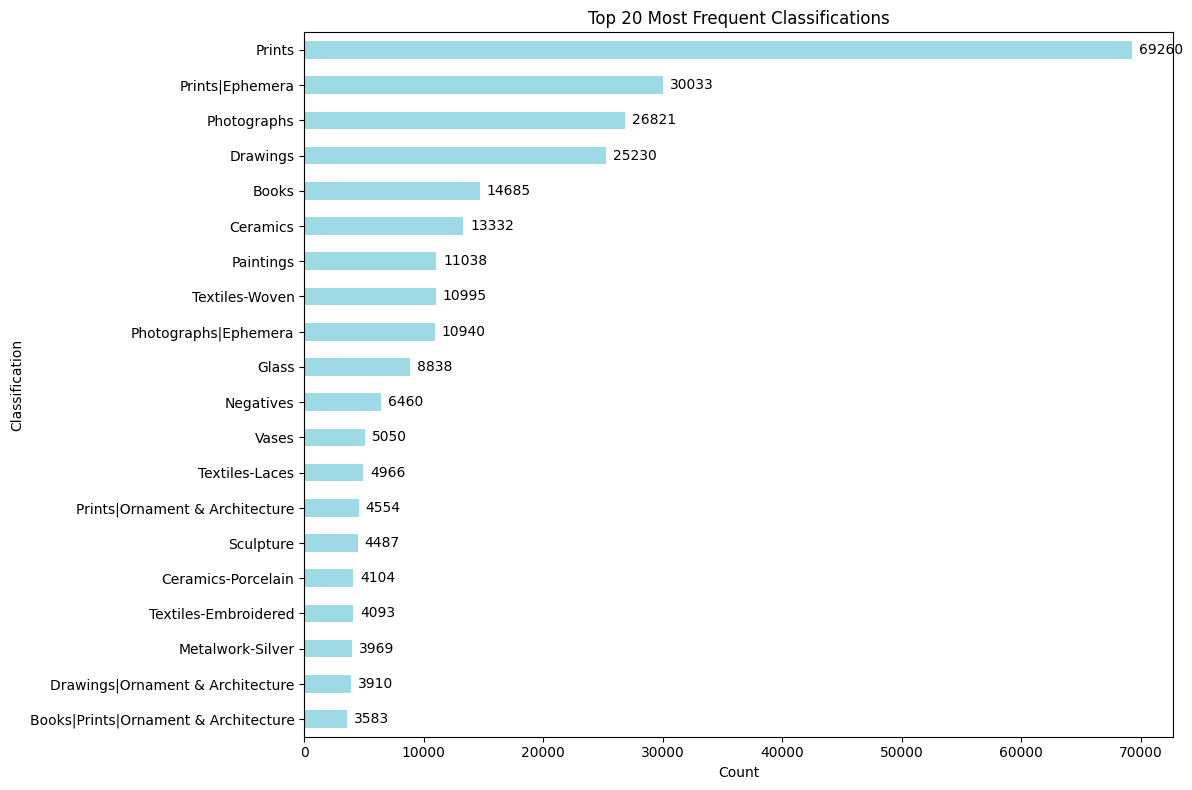

Plotting column: Rights and Reproduction


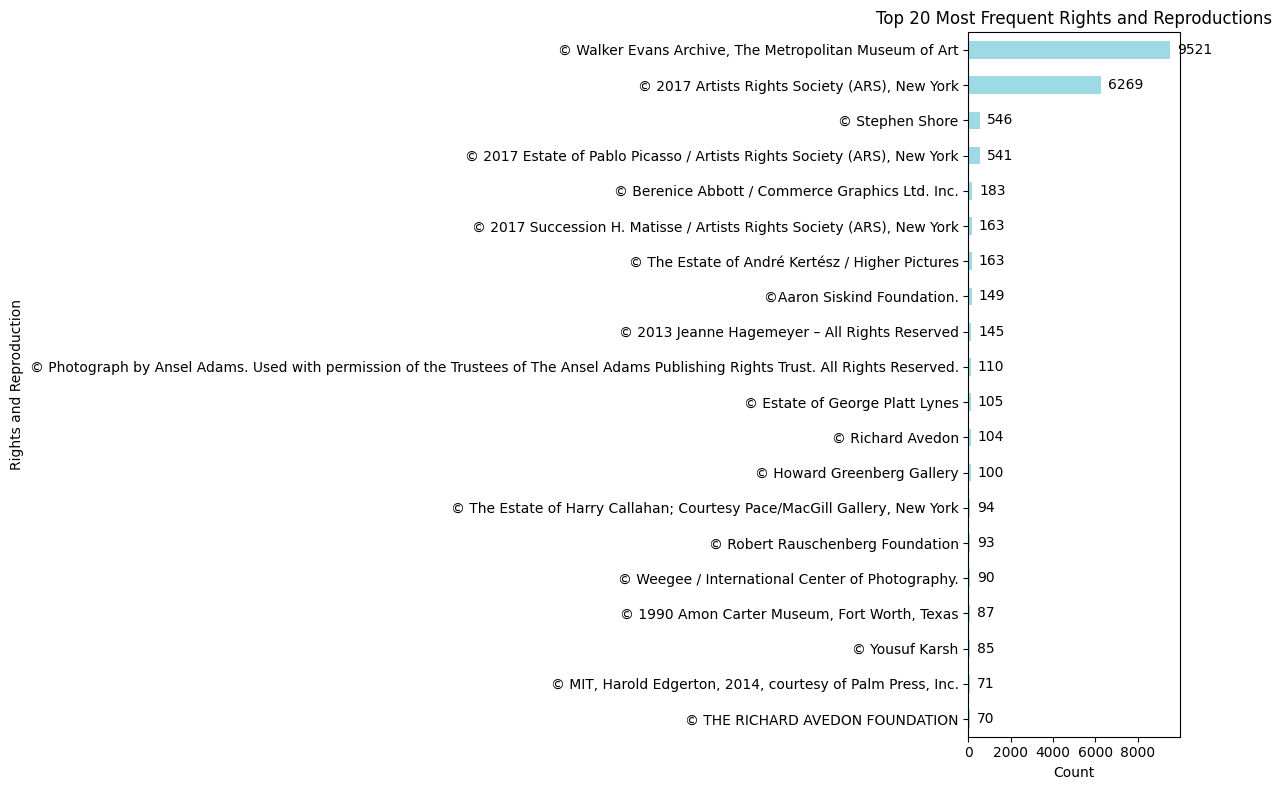

In [27]:
for col, color in zip(columns, colors):
    print(f"Plotting column: {col}")
    plot_top_frequencies(
        df,
        column_name=col,
        n=20,
        color=color,
        value_angle=0   # change to 30 or 90 if needed
    )


###2.2.3. Number of Missing Values for each Column

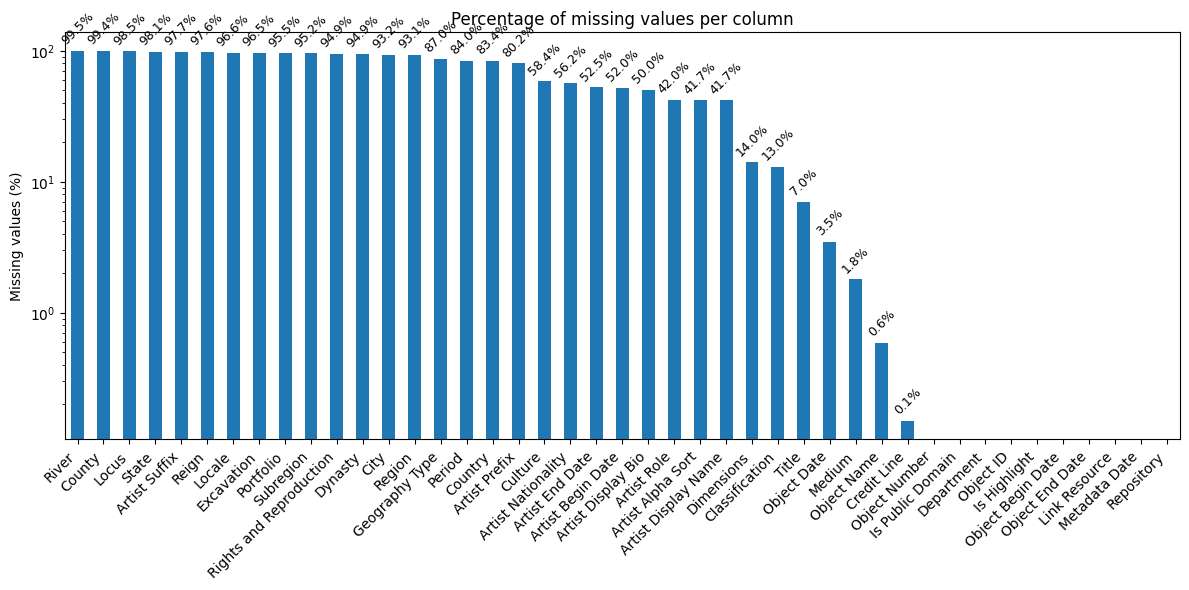

In [30]:
# percentage of missing values per column
missing_pct = df.isna().mean() * 100

# sort for readability
missing_pct = missing_pct.sort_values(ascending=False)

# bar plot
plt.figure(figsize=(12, 6))
ax = missing_pct.plot(kind="bar", logy=True)

plt.ylabel("Missing values (%)")
plt.title("Percentage of missing values per column")
plt.xticks(rotation=45, ha="right")

# add percentage labels
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=45,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

##2.3. Dipendency Discovery

###2.3.1. Functional Dependency

In [9]:
selected_columns = [
    col for col in df.columns
    if df[col].nunique() < 100 and df[col].dtype == "object"
]

df_subset = df[selected_columns]

In [11]:
cultural_cols = [
    "Culture", "Period", "Dynasty", "Reign",
    "Portfolio", "Classification", "Medium"
]


In [12]:
artist_cols = [
    "Artist Display Name",
    "Artist Alpha Sort",
    "Artist Nationality",
    "Artist Begin Date",
    "Artist End Date",
    "Artist Role"
]


In [13]:
geo_cols = [
    "Geography Type", "City", "State", "County",
    "Country", "Region", "Subregion"
]

In [14]:
def run_fd_discovery(df, columns, title):
    print(f"\n=== {title} ===")

    subset = df[columns].dropna(how="all")

    algo = db.fd.algorithms.FdMine()
    algo.load_data(table=subset)
    algo.execute()

    for fd in algo.get_fds():
        print(fd)


In [15]:
run_fd_discovery(df, cultural_cols, "Cultural FDs")
run_fd_discovery(df, artist_cols, "Artist FDs")
run_fd_discovery(df, geo_cols, "Geography FDs")



=== Cultural FDs ===

=== Artist FDs ===

=== Geography FDs ===


As you can there is no functional dependencies between columns

###2.3.2. Inclusion Dependencies (INDs)

In [24]:
# make a copy to avoid modifying original df
df_clean = df.copy()

# convert all object (text) columns to lowercase
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace("nan", pd.NA)
    )


In [25]:
# remove double spaces
df_clean = df_clean.replace(r"\s+", " ", regex=True)

# optional: remove trailing punctuation
df_clean = df_clean.replace(r"[.,;:]$", "", regex=True)


In [26]:
def inclusion_dependency(df, col_a, col_b, dropna=True):
    """
    Checks whether col_a ⊆ col_b.
    Returns (is_included, coverage_ratio).
    """
    if col_a not in df_clean.columns or col_b not in df_clean.columns:
        raise ValueError("Column not found in DataFrame")

    a_values = df[col_a]
    b_values = df[col_b]

    if dropna:
        a_values = a_values.dropna()
        b_values = b_values.dropna()

    set_a = set(a_values.unique())
    set_b = set(b_values.unique())

    if len(set_a) == 0:
        return False, 0.0

    intersection = set_a & set_b
    coverage = len(intersection) / len(set_a)

    return coverage == 1.0, coverage


In [27]:
def discover_inclusion_dependencies(df, columns, min_coverage=1.0):
    """
    Discovers inclusion dependencies among columns.
    min_coverage = 1.0 → exact IND
    min_coverage < 1.0 → approximate IND
    """
    results = []

    for col_a in columns:
        for col_b in columns:
            if col_a == col_b:
                continue

            is_ind, coverage = inclusion_dependency(df_clean, col_a, col_b)

            if coverage >= min_coverage:
                results.append({
                    "A ⊆ B": f"{col_a} ⊆ {col_b}",
                    "coverage": round(coverage, 3)
                })

    return pd.DataFrame(results)


In [28]:
geo_cols = [
    "City",
    "State",
    "County",
    "Country",
    "Region",
    "Subregion"
]

geo_ind = discover_inclusion_dependencies(
    df_clean,
    geo_cols,
    min_coverage=0.8  # allow small noise
)

geo_ind


,A ⊆ B,coverage
0,County ⊆ State,0.98


In [29]:
artist_cols = [
    "Artist Nationality",
    "Country"
]

artist_ind = discover_inclusion_dependencies(
    df_clean,
    artist_cols,
    min_coverage=0.5
)

artist_ind


""


In [30]:
artist_cols = [
    "Object Name",
    "Title",
    "Medium",
    "Classification"
]

artist_ind = discover_inclusion_dependencies(
    df_clean,
    artist_cols,
    min_coverage=0.5
)

artist_ind


""


###2.3.3. Matching Dependencies

In [31]:
from itertools import combinations
from difflib import SequenceMatcher

In [32]:
def string_similarity(a, b):
    if pd.isna(a) or pd.isna(b):
        return 0.0
    return SequenceMatcher(None, str(a), str(b)).ratio()

In [33]:
def exact_match(a, b):
    return int(a == b)

In [34]:
def generate_pairs(df, sample_size=2000, random_state=42):
    sampled = df.sample(sample_size, random_state=random_state)
    return list(combinations(sampled.index, 2))

In [36]:
from tqdm import tqdm

In [41]:
def evaluate_md(
    df,
    lhs_col,
    rhs_col,
    lhs_threshold=0.9,
    min_support=10
):
    pairs = generate_pairs(df)
    satisfied_lhs = 0
    satisfied_rhs = 0

    for i, j in tqdm(pairs):
        lhs_i = df.loc[i, lhs_col]
        lhs_j = df.loc[j, lhs_col]

        sim_lhs = string_similarity(lhs_i, lhs_j)

        if sim_lhs >= lhs_threshold:
            satisfied_lhs += 1

            rhs_i = df.loc[i, rhs_col]
            rhs_j = df.loc[j, rhs_col]

            # ✅ FIX: only compare if BOTH are not missing
            if pd.notna(rhs_i) and pd.notna(rhs_j):
                if rhs_i == rhs_j:
                    satisfied_rhs += 1

    if satisfied_lhs < min_support:
        return None

    confidence = satisfied_rhs / satisfied_lhs if satisfied_lhs > 0 else 0

    return {
        "MD": f"sim({lhs_col}) ≥ {lhs_threshold} ⇒ {rhs_col} equal",
        "support": satisfied_lhs,
        "confidence": round(confidence, 3)
    }


In [42]:
md_result = evaluate_md(
    df_clean,
    lhs_col="Artist Display Name",
    rhs_col="Artist Nationality",
    lhs_threshold=0.9
)

md_result


100%|██████████| 1999000/1999000 [01:35<00:00, 20954.89it/s]


{'MD': 'sim(Artist Display Name) ≥ 0.9 ⇒ Artist Nationality equal',
 'support': 2012,
 'confidence': 0.734}

In [49]:
def discover_mds(df, lhs_cols, rhs_cols, threshold=0.9):
    results = []

    for lhs in lhs_cols:
        for rhs in rhs_cols:
            if lhs == rhs:
                continue
            res = evaluate_md(df, lhs, rhs, threshold)
            results.append(res)

    return pd.DataFrame(results)


In [50]:
rhs_cols = ["Object Name",
    "Title",
    "Medium",
    "Classification"]

discover_Artist_df = discover_mds(df_clean, rhs_cols, rhs_cols)


100%|██████████| 1999000/1999000 [01:30<00:00, 22193.15it/s]


In [51]:
discover_Artist_df

,MD,support,confidence
0,sim(Object Name) ≥ 0.9 ⇒ Title equal,103917,0.014
1,sim(Object Name) ≥ 0.9 ⇒ Medium equal,103917,0.084
2,sim(Object Name) ≥ 0.9 ⇒ Classification equal,103917,0.615
3,sim(Title) ≥ 0.9 ⇒ Object Name equal,1639,0.948
4,sim(Title) ≥ 0.9 ⇒ Medium equal,1639,0.184
5,sim(Title) ≥ 0.9 ⇒ Classification equal,1639,0.277
6,sim(Medium) ≥ 0.9 ⇒ Object Name equal,19195,0.476
7,sim(Medium) ≥ 0.9 ⇒ Title equal,19195,0.011
8,sim(Medium) ≥ 0.9 ⇒ Classification equal,19195,0.705
9,sim(Classification) ≥ 0.9 ⇒ Object Name equal,82490,0.764


In [ ]:
rhs_cols = ["City",
    "State",
    "County",
    "Country",
    "Region",
    "Subregion"]

discover_Artist_df = discover_mds(df_clean, rhs_cols, rhs_cols)

In [ ]:
rhs_cols = ["Artist Display Name", "Artist Nationality", "Artist Begin Date", "Artist End Date", "Artist Alpha Sort"]

discover_Artist_df = discover_mds(df_clean, rhs_cols, rhs_cols)


###2.3.4 Association Rules

##3. Data Quality Assesment

###3.1. Cardinalities

###3.2. Completness

###3.3. Consistency

##4. Data Wrangling

#Data Quality Assessment

In [ ]:
#Completeness
null_cnt= dataset.isnull().sum().sum()
not_null_cnt = dataset.notnull().sum().sum()
total_cnt = dataset.size
print("The dataset has a total of {} missing values".format(null_cnt))
print("The dataset has a total of {} non missing values".format(not_null_cnt))
print("The dataset has a total of {} values".format(total_cnt))

completeness = not_null_cnt/total_cnt
completeness = '{0:.2f}%'.format(completeness*100)
print("Completeness Evaluation: "+completeness)

#Uniqueness
unique_cnt = dataset.nunique().sum()
print("The dataset has a total of {} unique values".format(unique_cnt))
uniqueness = unique_cnt/total_cnt
uniqueness = '{0:.2f}%'.format(uniqueness*100)
print("Uniqueness Evaluation: "+ uniqueness)

#Consistency
consistenciness = unique_cnt / not_null_cnt
consistenciness = '{0:.2f}%'.format(consistenciness*100)
print("Consistenciness Evaluation: "+ consistenciness)

# Timeliness
VOLATILITY = 100  # Days
today = datetime(2025, 12, 25)
dataset['Metadata Date'] = pd.to_datetime( dataset['Metadata Date'], errors='coerce') # Changed 'Joined' to 'Metadata Date'
dataset['Currency'] =(today - dataset['Metadata Date']).dt.days # Changed 'Joined' to 'Metadata Date'
dataset['Timeliness'] = np.where(
    VOLATILITY > dataset['Currency'],
    1 - ( dataset['Currency'] / VOLATILITY),
    0
)
print("Average Timeliness:", dataset['Timeliness'].mean())
print("Maximum Timeliness:",  dataset['Timeliness'].max())
print("Minimum Timeliness:",  dataset['Timeliness'].min())

dataset.to_csv('MET_data_with_timeliness.csv', index=False)
dataset

The dataset has a total of 9500980 missing values
The dataset has a total of 9771749 non missing values
The dataset has a total of 19272729 values
Completeness Evaluation: 50.70%
The dataset has a total of 2203547 unique values
Uniqueness Evaluation: 11.43%
Consistenciness Evaluation: 22.55%
Average Timeliness: 0.0
Maximum Timeliness: 0.0
Minimum Timeliness: 0.0


,Object Number,Is Highlight,Is Public Domain,Object ID,Department,Object Name,Title,Culture,Period,Dynasty,...,Locus,Excavation,River,Classification,Rights and Reproduction,Link Resource,Metadata Date,Repository,Currency,Timeliness
0,1979.486.1,False,False,1,American Decorative Arts,Coin,One-dollar Liberty Head Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/1,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
1,1980.264.5,False,False,2,American Decorative Arts,Coin,Ten-dollar Liberty Head Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/2,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
2,67.265.9,False,False,3,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/3,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
3,67.265.10,False,False,4,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/4,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
4,67.265.11,False,False,5,American Decorative Arts,Coin,Two-and-a-Half Dollar Coin,NaN,NaN,NaN,...,NaN,NaN,NaN,Metal,NaN,http://www.metmuseum.org/art/collection/search/5,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448198,1994.338.10,False,False,750826,Drawings and Prints,Print,"Eric, King of Sweden",NaN,NaN,NaN,...,NaN,NaN,NaN,Prints,NaN,http://www.metmuseum.org/art/collection/search...,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
448199,1994.338.12,False,False,750827,Drawings and Prints,Print,Louis XIII of France,NaN,NaN,NaN,...,NaN,NaN,NaN,Prints,NaN,http://www.metmuseum.org/art/collection/search...,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
448200,1994.338.15,False,False,750828,Drawings and Prints,Print,George Rem,NaN,NaN,NaN,...,NaN,NaN,NaN,Prints,NaN,http://www.metmuseum.org/art/collection/search...,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0
448201,1994.338.16,False,False,750829,Drawings and Prints,Print,Henry de la Tour d'Auvergne,NaN,NaN,NaN,...,NaN,NaN,NaN,Prints,NaN,http://www.metmuseum.org/art/collection/search...,2017-04-03 08:00:08,"Metropolitan Museum of Art, New York, NY",3187,0.0


We chose the 'Metadata Date' column for the timeliness calculation because its description, "Timestamp of the most recent metadata update," directly reflects how recently the data record was refreshed. This makes it the most appropriate column to assess the timeliness of the dataset's information.

The timeliness value of 0.0 across all entries isn't meaningless; it's an accurate reflection of the data's age compared to our defined VOLATILITY threshold. Since all 'Metadata Dates' are from April 2017, and our today variable is set to December 2025, the data is over 3000 days old. With a VOLATILITY of 100 days, any data older than 100 days receives a timeliness score of 0. This means, according to our current definition, none of the data is considered recent.

#Data Profiling

## **Correlation of the Numerical Features**

In [ ]:
#select the columns that are numerical
numerical_columns = dataset.select_dtypes(include=[np.number]).columns
print("The numerical columns are: ")
print(numerical_columns)

The numerical columns are: 
Index(['Object ID', 'Object Begin Date', 'Object End Date', 'Currency',
       'Timeliness'],
      dtype='object')


In [ ]:
# Keep only columns with at least 2 unique non-null values
numerical_columns = [
    col for col in numerical_columns
    if dataset[col].nunique(dropna=True) > 1
]


In [ ]:
all_numeric = dataset.select_dtypes(include=[np.number]).columns
valid_numeric = numerical_columns

removed = set(all_numeric) - set(valid_numeric)
print("Removed numerical columns (constant or empty):", removed)


Removed numerical columns (constant or empty): {'Timeliness', 'Currency'}


In [ ]:
# select the style from fivethityeight website
plt.style.use('fivethirtyeight')
mpl.rcParams['lines.linewidth'] = 2

# predefined figsize
figsize=(12,12)

warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'png'
%matplotlib inline

## **Data Cleaning (Missing Value)**

<Axes: >

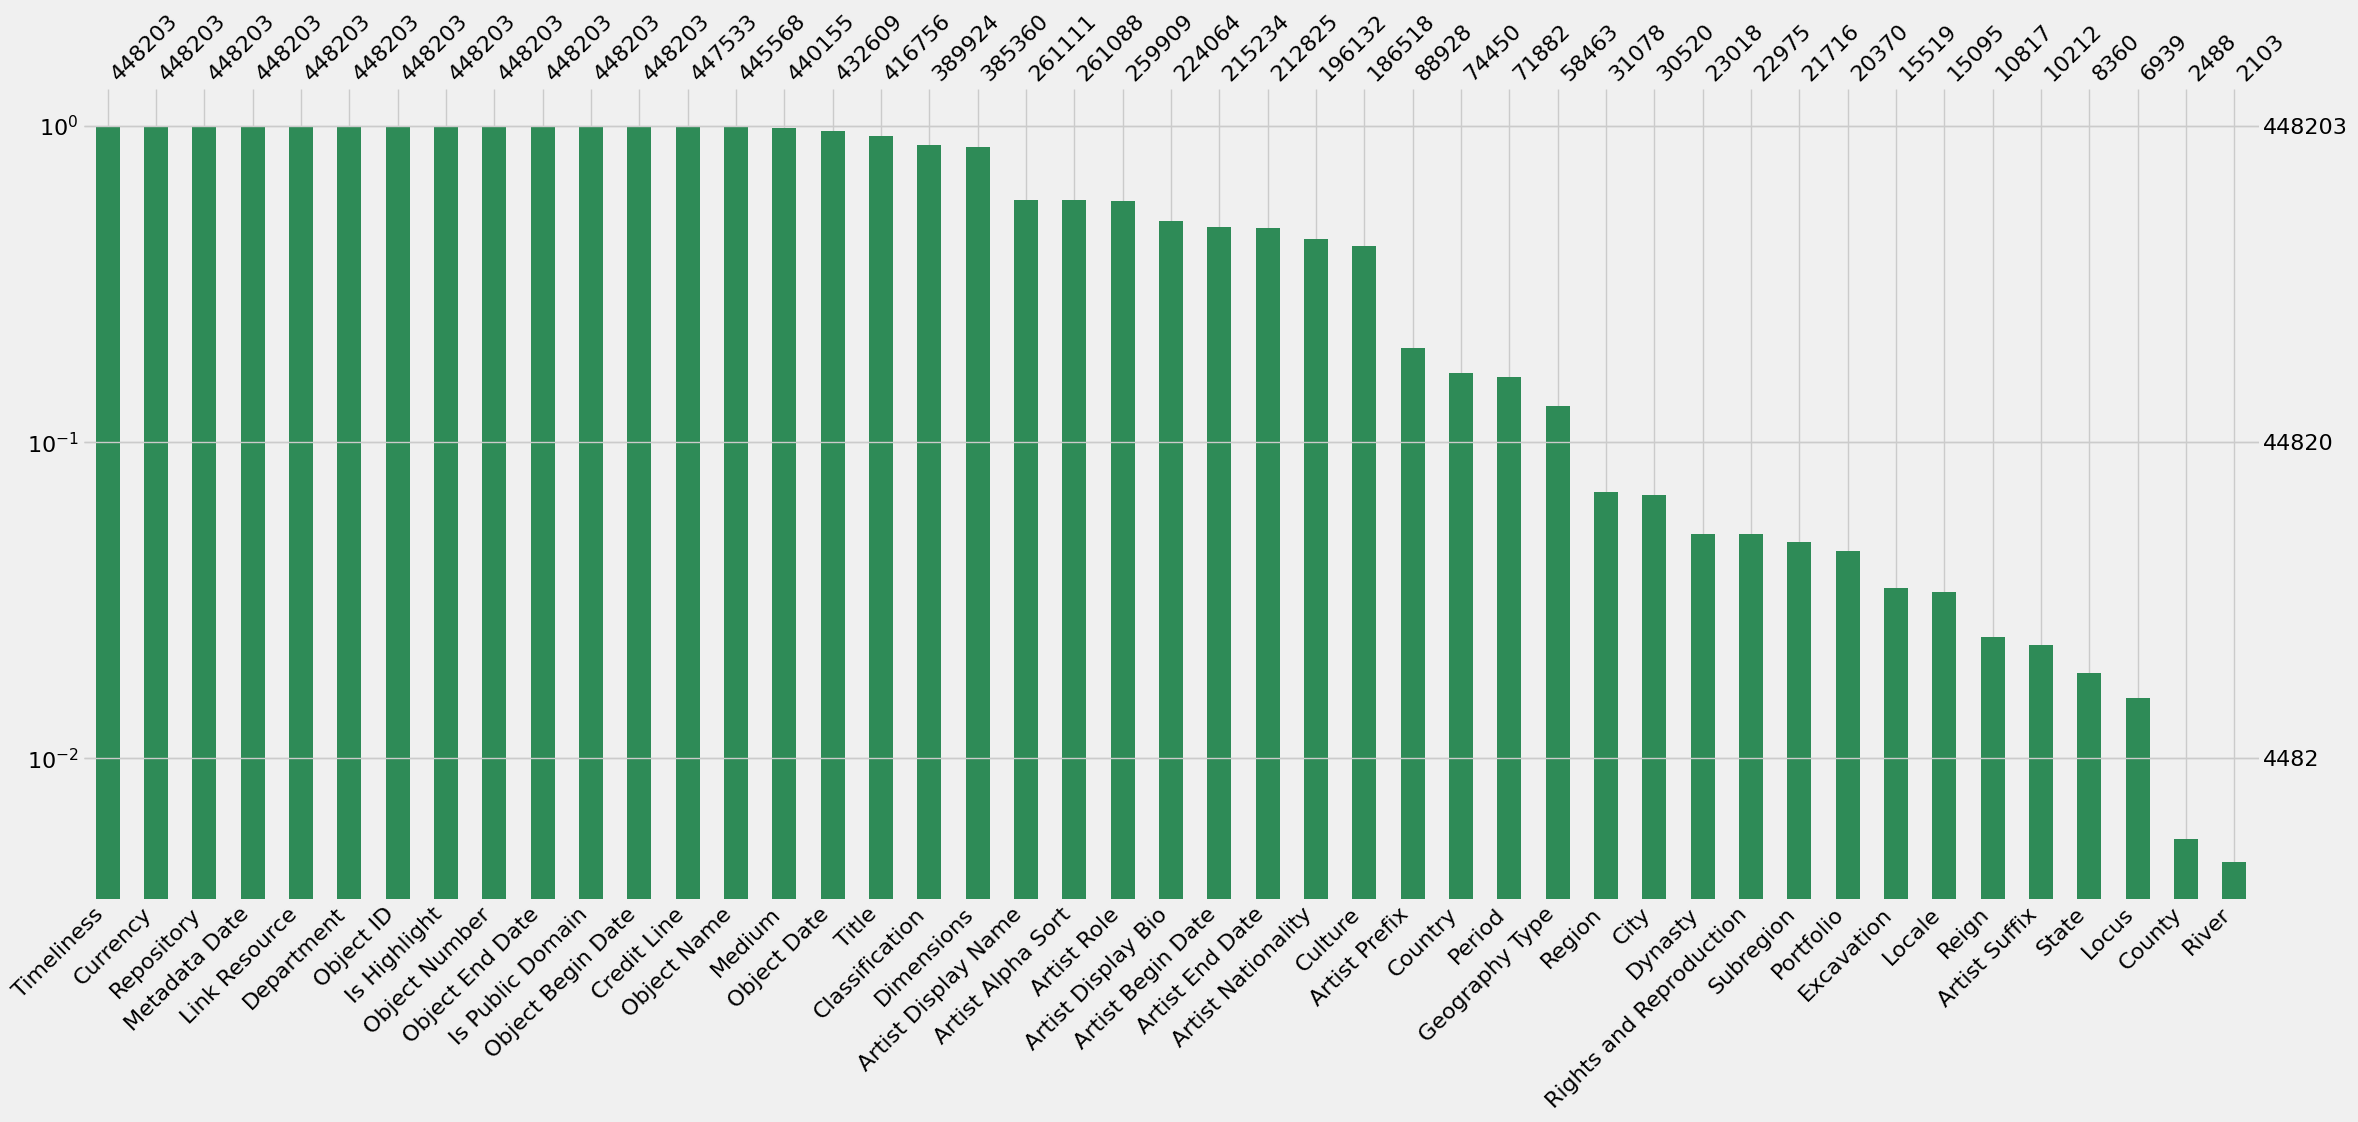

In [ ]:
msno.bar(dataset, color="seagreen", log=True, sort="descending")

In [ ]:
{col: [dataset[col].isnull().sum(), f'% {np.round(np.mean(dataset[col].isnull()*100), 3)}'
      ] for col in dataset.columns if dataset[col].isnull().any()}

{'Object Name': [np.int64(2635), '% 0.588'],
 'Title': [np.int64(31447), '% 7.016'],
 'Culture': [np.int64(261685), '% 58.385'],
 'Period': [np.int64(376321), '% 83.962'],
 'Dynasty': [np.int64(425185), '% 94.864'],
 'Reign': [np.int64(437386), '% 97.587'],
 'Portfolio': [np.int64(427833), '% 95.455'],
 'Artist Role': [np.int64(188294), '% 42.011'],
 'Artist Prefix': [np.int64(359275), '% 80.159'],
 'Artist Display Name': [np.int64(187092), '% 41.743'],
 'Artist Display Bio': [np.int64(224139), '% 50.008'],
 'Artist Suffix': [np.int64(437991), '% 97.722'],
 'Artist Alpha Sort': [np.int64(187115), '% 41.748'],
 'Artist Nationality': [np.int64(252071), '% 56.24'],
 'Artist Begin Date': [np.int64(232969), '% 51.978'],
 'Artist End Date': [np.int64(235378), '% 52.516'],
 'Object Date': [np.int64(15594), '% 3.479'],
 'Medium': [np.int64(8048), '% 1.796'],
 'Dimensions': [np.int64(62843), '% 14.021'],
 'Credit Line': [np.int64(670), '% 0.149'],
 'Geography Type': [np.int64(389740), '% 86.956

## **Data Cleaning (Data Transformation)**

We remove all column with missing value more than 90%.

Fill missing values in the "Medium", "Object Date", "Titlle", "classification", "Dimension" column with the column mean.

In [ ]:
# Threshold: keep columns with at least 20% non-missing values
threshold = 0.05

dataset_cleaned = dataset.dropna(axis=1, thresh=int(threshold * len(dataset)))

print("Removed columns:")
removed_cols = set(dataset.columns) - set(dataset_cleaned.columns)
print(removed_cols)

print("\nRemaining columns:", dataset_cleaned.shape[1])


Removed columns:
{'Locale', 'Subregion', 'State', 'Excavation', 'River', 'Locus', 'Artist Suffix', 'Portfolio', 'County', 'Reign'}

Remaining columns: 35


## **Non-Numerical Analysis Columns:**

In [ ]:
# Select non-numerical columns
non_numerical_cols = dataset_cleaned.select_dtypes(exclude=['number']).columns

print("Non-numerical columns:")
print(non_numerical_cols)

Non-numerical columns:
Index(['Object Number', 'Is Highlight', 'Is Public Domain', 'Department',
       'Object Name', 'Title', 'Culture', 'Period', 'Dynasty', 'Artist Role',
       'Artist Prefix', 'Artist Display Name', 'Artist Display Bio',
       'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date',
       'Artist End Date', 'Object Date', 'Medium', 'Dimensions', 'Credit Line',
       'Geography Type', 'City', 'Country', 'Region', 'Classification',
       'Rights and Reproduction', 'Link Resource', 'Metadata Date',
       'Repository'],
      dtype='object')


In [ ]:
# Select non-numerical columns
non_numerical_cols = dataset_cleaned.select_dtypes(exclude=['number']).columns

print("Non-numerical columns:")
print(non_numerical_cols)

Non-numerical columns:
Index(['Object Number', 'Is Highlight', 'Is Public Domain', 'Department',
       'Object Name', 'Title', 'Culture', 'Period', 'Dynasty', 'Artist Role',
       'Artist Prefix', 'Artist Display Name', 'Artist Display Bio',
       'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date',
       'Artist End Date', 'Object Date', 'Medium', 'Dimensions', 'Credit Line',
       'Geography Type', 'City', 'Country', 'Region', 'Classification',
       'Rights and Reproduction', 'Link Resource', 'Metadata Date',
       'Repository'],
      dtype='object')


In [ ]:
# Columns to remove
columns_to_drop = [
    "Object Number",
    "Title",
    "Artist Display Name",
    "Artist Display Bio",
    "Artist Alpha Sort",
    "Dimensions",
    "Credit Line",
    "Link Resource",
    "Metadata Date",
    "Repository",
    "Period",
    "Dynasty",
    "Artist Prefix",
    "Geography Type",
    "Region",
    "Rights and Reproduction",
    "Object Date"
]

# Drop columns (ignore errors avoids issues if a column is missing)
dataset_cleaned = dataset_cleaned.drop(columns=columns_to_drop, errors="ignore")

print("Remaining columns:")
print(dataset_cleaned.columns)
print("\nDataset shape:", dataset_cleaned.shape)


Remaining columns:
Index(['Is Highlight', 'Is Public Domain', 'Object ID', 'Department',
       'Object Name', 'Culture', 'Artist Role', 'Artist Nationality',
       'Artist Begin Date', 'Artist End Date', 'Object Begin Date',
       'Object End Date', 'Medium', 'City', 'Country', 'Classification',
       'Currency', 'Timeliness'],
      dtype='object')

Dataset shape: (448203, 18)


In [ ]:
# Select non-numerical columns
non_numerical_cols = dataset_cleaned.select_dtypes(exclude=['number']).columns

print("Non-numerical columns:")
print(non_numerical_cols)

Non-numerical columns:
Index(['Is Highlight', 'Is Public Domain', 'Department', 'Object Name',
       'Culture', 'Artist Role', 'Artist Nationality', 'Artist Begin Date',
       'Artist End Date', 'Medium', 'City', 'Country', 'Classification'],
      dtype='object')


### **Convert string date to date time object**

In [ ]:
dataset_cleaned["Artist Begin Date"] = pd.to_datetime(
    dataset_cleaned["Artist Begin Date"]
    .astype(str)
    .str.split("|")
    .str[0]
    .str.strip(),
    format="%Y",
    errors="coerce"
)

In [ ]:
dataset_cleaned["Artist End Date"] = pd.to_datetime(
    dataset_cleaned["Artist End Date"]
    .astype(str)
    .str.split("|")
    .str[0]
    .str.strip(),
    format="%Y",
    errors="coerce"
)

### **Department column**

In [ ]:
print_unique_values(df_cleaned, "Department", 300)

In [ ]:
plot_top_frequencies(dataset_cleaned, 'Department', n=20)

In [ ]:
dataset_cleaned['Department'] = dataset_cleaned['Department'].astype('category', errors='raise')

### **Object Name Column**

In [ ]:
print_unique_values(df_cleaned, "Object Name", 300)

In [ ]:
plot_top_frequencies(dataset_cleaned, 'Object Name', n=20)

In [ ]:
dataset_cleaned['Object Name'] = dataset_cleaned['Object Name'].astype('category', errors='raise')

### **Culture Column Cleaning**

Culture metadata is cleaned and standardized to ensure one unambiguous cultural label per record.

In [ ]:
import re

def clean_culture(text):
    if pd.isna(text):
        return "unknown"
    text = text.lower()
    # Remove parentheses content
    text = re.sub(r"\(.*?\)", "", text)
    # Remove uncertainty / market phrases
    text = re.sub(
        r"\b(probably|possibly|for .*? market|for export|textile)\b",
        "",
        text
    )
    # Split on first delimiter: or, ;, :, ,
    text = re.split(r"\bor\b|;|:|,|-|and", text)[0]
    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Clean culture text
dataset_cleaned["Culture"] = dataset_cleaned["Culture"].apply(clean_culture)
# Split into list
dataset_cleaned["Culture"] = dataset_cleaned["Culture"].str.split(r",| or ;")
# Keep only the first value
dataset_cleaned["Culture"] = dataset_cleaned["Culture"].str[0].str.strip()


In [ ]:
print_unique_values(df_cleaned, "Culture", 50)

In [ ]:
plot_top_frequencies(dataset_cleaned, 'Culture', n=20)

In [ ]:
dataset_cleaned['Culture'] = dataset_cleaned['Culture'].astype('category', errors='raise')

### **Artist Role Cleaning**

In [ ]:
print_unique_values(df_cleaned, "Artist Role", 50)

In [ ]:
# Keep only the leftmost role in Artist Role
dataset_cleaned["Artist Role"] = (
    dataset_cleaned["Artist Role"]
    .astype(str)
    .str.split("|")
    .str[0]
    .str.strip()
    .replace("nan", "Unknown")
)

In [ ]:
plot_top_frequencies(dataset_cleaned, 'Artist Role', n=20)

In [ ]:
dataset_cleaned['Artist Role'] = dataset_cleaned['Artist Role'].astype('category', errors='raise')

### **Artist Nationality cleaning**

In [ ]:
import re
import pandas as pd

def clean_nationality(text):
    if pd.isna(text):
        return "unknown"
    text = text.lower()
    # Remove parentheses content
    text = re.sub(r"\(.*?\)", "", text)
    # Remove uncertainty words
    text = re.sub(r"\b(probably|possibly)\b", "", text)
    # Keep only the leftmost value
    text = re.split(r"\bor\b|\band\b|\bborn\b|\||,|;|:|/|-|\?", text, maxsplit=1)[0]
    text = text.strip()
    return text

In [ ]:
print_unique_values(df_cleaned, "Artist Nationality", 50)

In [ ]:
dataset_cleaned["Artist Nationality"] = dataset_cleaned["Artist Nationality"].apply(clean_nationality)

In [ ]:
plot_top_frequencies(dataset_cleaned, 'Artist Nationality', n=20)

In [ ]:
dataset_cleaned['Artist Nationality'] = dataset_cleaned['Artist Nationality'].astype('category', errors='raise')

### **Medium Data Cleaning**

In [ ]:
import re

def extract_primary_material(text):
    if pd.isna(text):
        return "unknown"
    text = text.lower()
    # remove parentheses
    text = re.sub(r"\(.*?\)", "", text)
    # cut at separators
    text = re.split(r"\bor\b|,|;|:|and", text, maxsplit=1)[0]
    # keep first word only
    text = text.strip().split()[0] if text.strip() else "unknown"
    return text

In [ ]:
dataset_cleaned["Medium"] = dataset_cleaned["Medium"].apply(extract_primary_material)

In [ ]:
plot_top_frequencies(dataset_cleaned, 'Medium', n=20)

In [ ]:
dataset_cleaned['Medium'] = dataset_cleaned['Medium'].astype('category', errors='raise')

### **Due to the huge number of nukonw value we ignored the City Column and Country**

In [ ]:
print(f"Shape before dropping 'City' and 'Country': {dataset_cleaned.shape}")
columns_to_drop_city_country = ['City', 'Country']
dataset_cleaned = dataset_cleaned.drop(columns=columns_to_drop_city_country, errors='ignore')
print(f"Shape after dropping 'City' and 'Country': {dataset_cleaned.shape}")

Shape before dropping 'City' and 'Country': (448203, 18)
Shape after dropping 'City' and 'Country': (448203, 16)


### **Classification column cleaning**

In [ ]:
print_unique_values(df_cleaned, "Classification", 20)

In [ ]:
plot_top_frequencies(dataset_cleaned, 'Classification', n=20)

In [ ]:
dataset_cleaned['Classification'] = dataset_cleaned['Classification'].astype('category', errors='raise')

In [24]:
#check the type of dataset columns
for col, dtype in df.dtypes.items():
    print(f"{col}: {dtype}")


Object Number: object
Is Highlight: bool
Is Public Domain: bool
Object ID: int64
Department: object
Object Name: object
Title: object
Culture: object
Period: object
Dynasty: object
Reign: object
Portfolio: object
Artist Role: object
Artist Prefix: object
Artist Display Name: object
Artist Display Bio: object
Artist Suffix: object
Artist Alpha Sort: object
Artist Nationality: object
Artist Begin Date: object
Artist End Date: object
Object Date: object
Object Begin Date: int64
Object End Date: int64
Medium: object
Dimensions: object
Credit Line: object
Geography Type: object
City: object
State: object
County: object
Country: object
Region: object
Subregion: object
Locale: object
Locus: object
Excavation: object
River: object
Classification: object
Rights and Reproduction: object
Link Resource: object
Metadata Date: object
Repository: object


## **Numerical Column Analysis**

In [ ]:
# Select numerical columns
numerical_cols = dataset_cleaned.select_dtypes(include=['number']).columns

print("Numerical columns:")
print(numerical_cols)


Numerical columns:
Index(['Object ID', 'Object Begin Date', 'Object End Date', 'Currency',
       'Timeliness'],
      dtype='object')


### **Object ID is removed. it has unique value for each object**

In [ ]:
c_name = 'Object End Date'
unique_ = dataset_cleaned[c_name].unique()
print(f"Number of Unique values in {c_name} column: {len(unique_)}")
for i in unique_[:100]:
    print(i)

In [ ]:
dataset_cleaned["Object Begin Date"] = pd.to_datetime(
    dataset_cleaned["Object Begin Date"],
    format="%Y",
    errors="coerce"
)


In [ ]:
dataset_cleaned["Object End Date"] = pd.to_datetime(
    dataset_cleaned["Object End Date"],
    format="%Y",
    errors="coerce"
)


In [ ]:
# from mlxtend.frequent_patterns import apriori, association_rules

# # Prepare transactions
# transactions = (
#     dataset_cleaned[["Object Name", "Classification"]]
#     .astype(str)
#     .agg(",".join, axis=1)
#     .str.get_dummies(sep=",")
# )

# from mlxtend.preprocessing import TransactionEncoder
# from mlxtend.frequent_patterns import fpgrowth, association_rules

# te = TransactionEncoder()
# te_ary = te.fit(transactions).transform(transactions)
# df_trans = pd.DataFrame(te_ary, columns=te.columns_)

# frequent = fpgrowth(
#     df_trans,
#     min_support=0.05,     # increase support to reduce memory
#     use_colnames=True
# )

# rules = association_rules(
#     frequent,
#     metric="confidence",
#     min_threshold=0.7
# )

# rules.sort_values("lift", ascending=False).head(10)


#Other Group Code

The follwing columns are not numerical, so they must be checked further for cleaning :

In [ ]:
# Select non-numerical columns
non_numerical_cols = dataset_cleaned.select_dtypes(exclude=['number']).columns

print("Non-numerical columns:")
print(non_numerical_cols)



Non-numerical columns:
Index(['Object Number', 'Is Highlight', 'Is Public Domain', 'Department',
       'Object Name', 'Title', 'Culture', 'Period', 'Artist Role',
       'Artist Prefix', 'Artist Display Name', 'Artist Display Bio',
       'Artist Alpha Sort', 'Artist Nationality', 'Artist Begin Date',
       'Artist End Date', 'Object Date', 'Medium', 'Dimensions', 'Credit Line',
       'Geography Type', 'Country', 'Classification', 'Link Resource',
       'Metadata Date', 'Repository'],
      dtype='object')


In [ ]:
# Columns suitable for non-numerical (categorical) analysis
categorical_cols = [
    "Department",
    "Object Name",
    "Culture",
    "Period",
    "Artist Role",
    "Artist Nationality",
    "Medium",
    "Classification",
    "Geography Type",
    "Country",
    "Repository"
]

# Keep only the suitable non-numerical columns
dataset_categorical = dataset[categorical_cols].copy()

print("Remaining columns for non-numerical analysis:")
print(dataset_categorical.columns)
print("\nShape:", dataset_categorical.shape)


Remaining columns for non-numerical analysis:
Index(['Department', 'Object Name', 'Culture', 'Period', 'Artist Role',
       'Artist Nationality', 'Medium', 'Classification', 'Geography Type',
       'Country', 'Repository'],
      dtype='object')

Shape: (448203, 11)


In [ ]:
dataset_cleaned[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448203 entries, 0 to 448202
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Department          448203 non-null  object
 1   Object Name         445568 non-null  object
 2   Culture             186518 non-null  object
 3   Period              71882 non-null   object
 4   Artist Role         259909 non-null  object
 5   Artist Nationality  196132 non-null  object
 6   Medium              448203 non-null  object
 7   Classification      448203 non-null  object
 8   Geography Type      58463 non-null   object
 9   Country             74450 non-null   object
 10  Repository          448203 non-null  object
dtypes: object(11)
memory usage: 37.6+ MB


<Axes: xlabel='Department'>

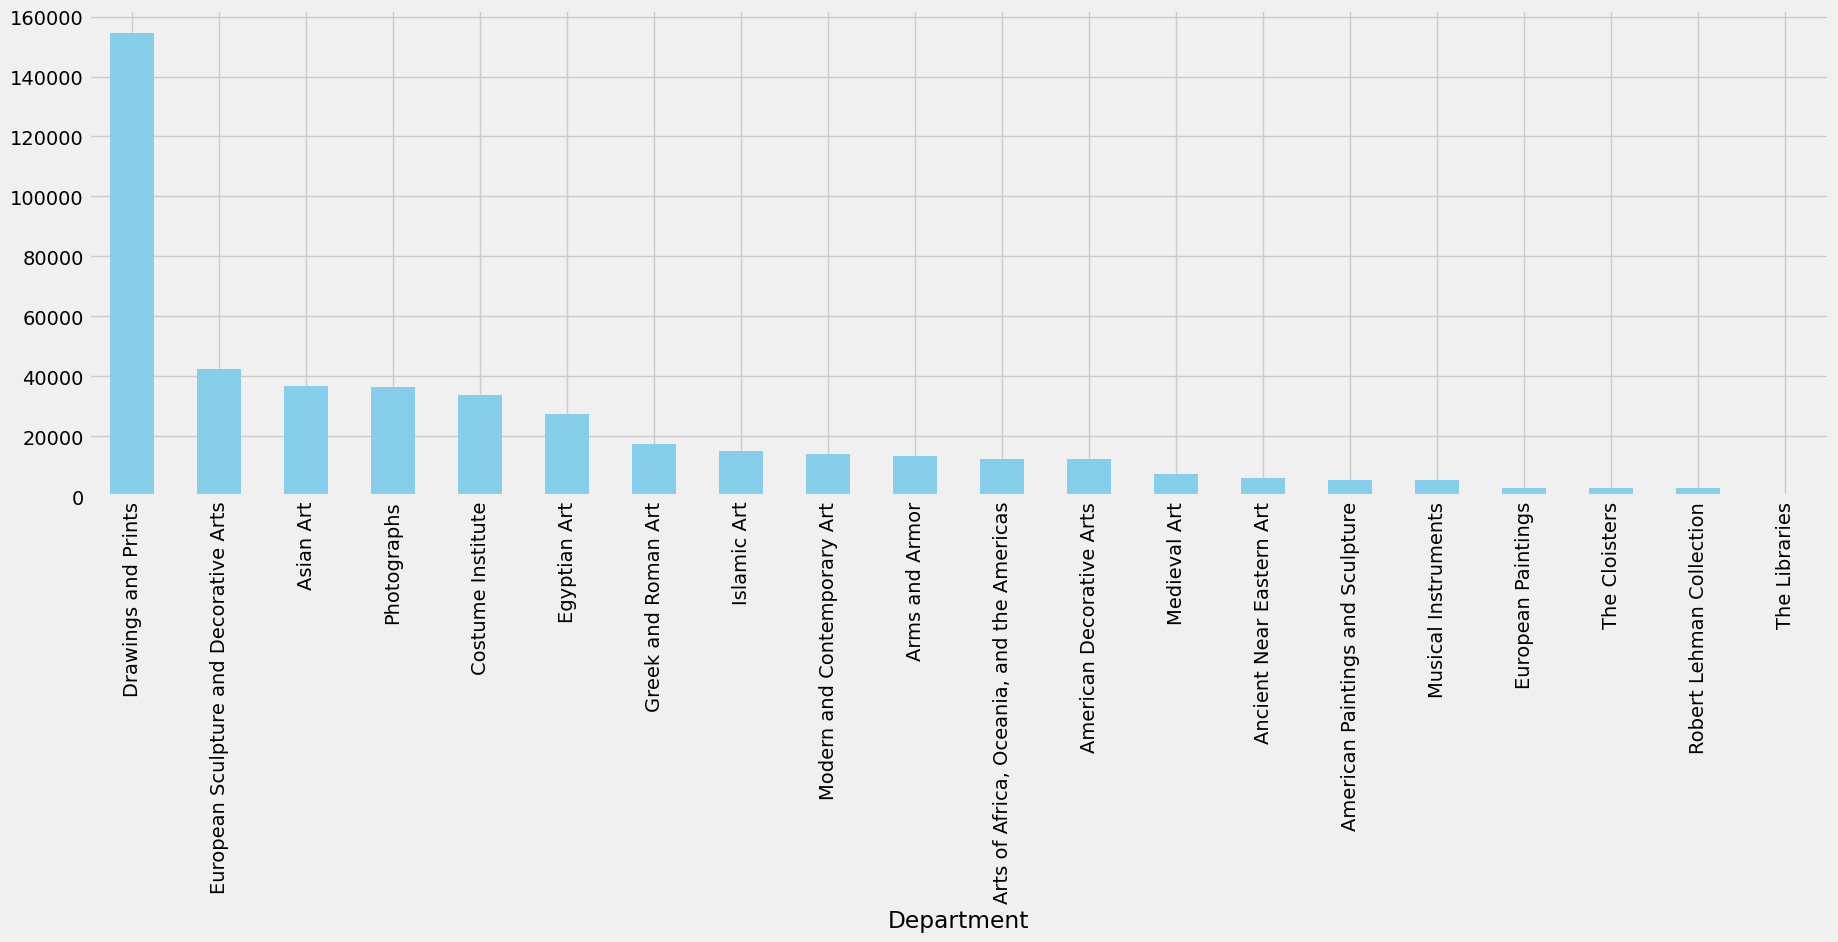

In [ ]:
dataset_cleaned['Department'].value_counts().plot(kind='bar', figsize=(20, 6), color='skyblue')

**Department**

In [ ]:
dataset['Department'].value_counts()[:10] , dataset['Department'].value_counts()[-10:]

(Department
 Drawings and Prints                       154445
 European Sculpture and Decorative Arts     42528
 Asian Art                                  36727
 Photographs                                36258
 Costume Institute                          33681
 Egyptian Art                               27542
 Greek and Roman Art                        17292
 Islamic Art                                15082
 Modern and Contemporary Art                13991
 Arms and Armor                             13486
 Name: count, dtype: int64,
 Department
 Arts of Africa, Oceania, and the Americas    12427
 American Decorative Arts                     12330
 Medieval Art                                  7343
 Ancient Near Eastern Art                      6185
 American Paintings and Sculpture              5451
 Musical Instruments                           5303
 European Paintings                            2760
 The Cloisters                                 2628
 Robert Lehman Collection       

According to the above plot, we conclude that all the values in the 'Department' column are valid and consistent. Therefore, no further step for cleaning is required. Since the column values are categorical so, we change the type of the column to ctagorical to help reduce memory usage and make certain operations faster.

In [ ]:
dataset_cleaned['Department'] = dataset['Department'].astype('category', errors='raise')

**Object Name**

<Axes: xlabel='Object Name'>

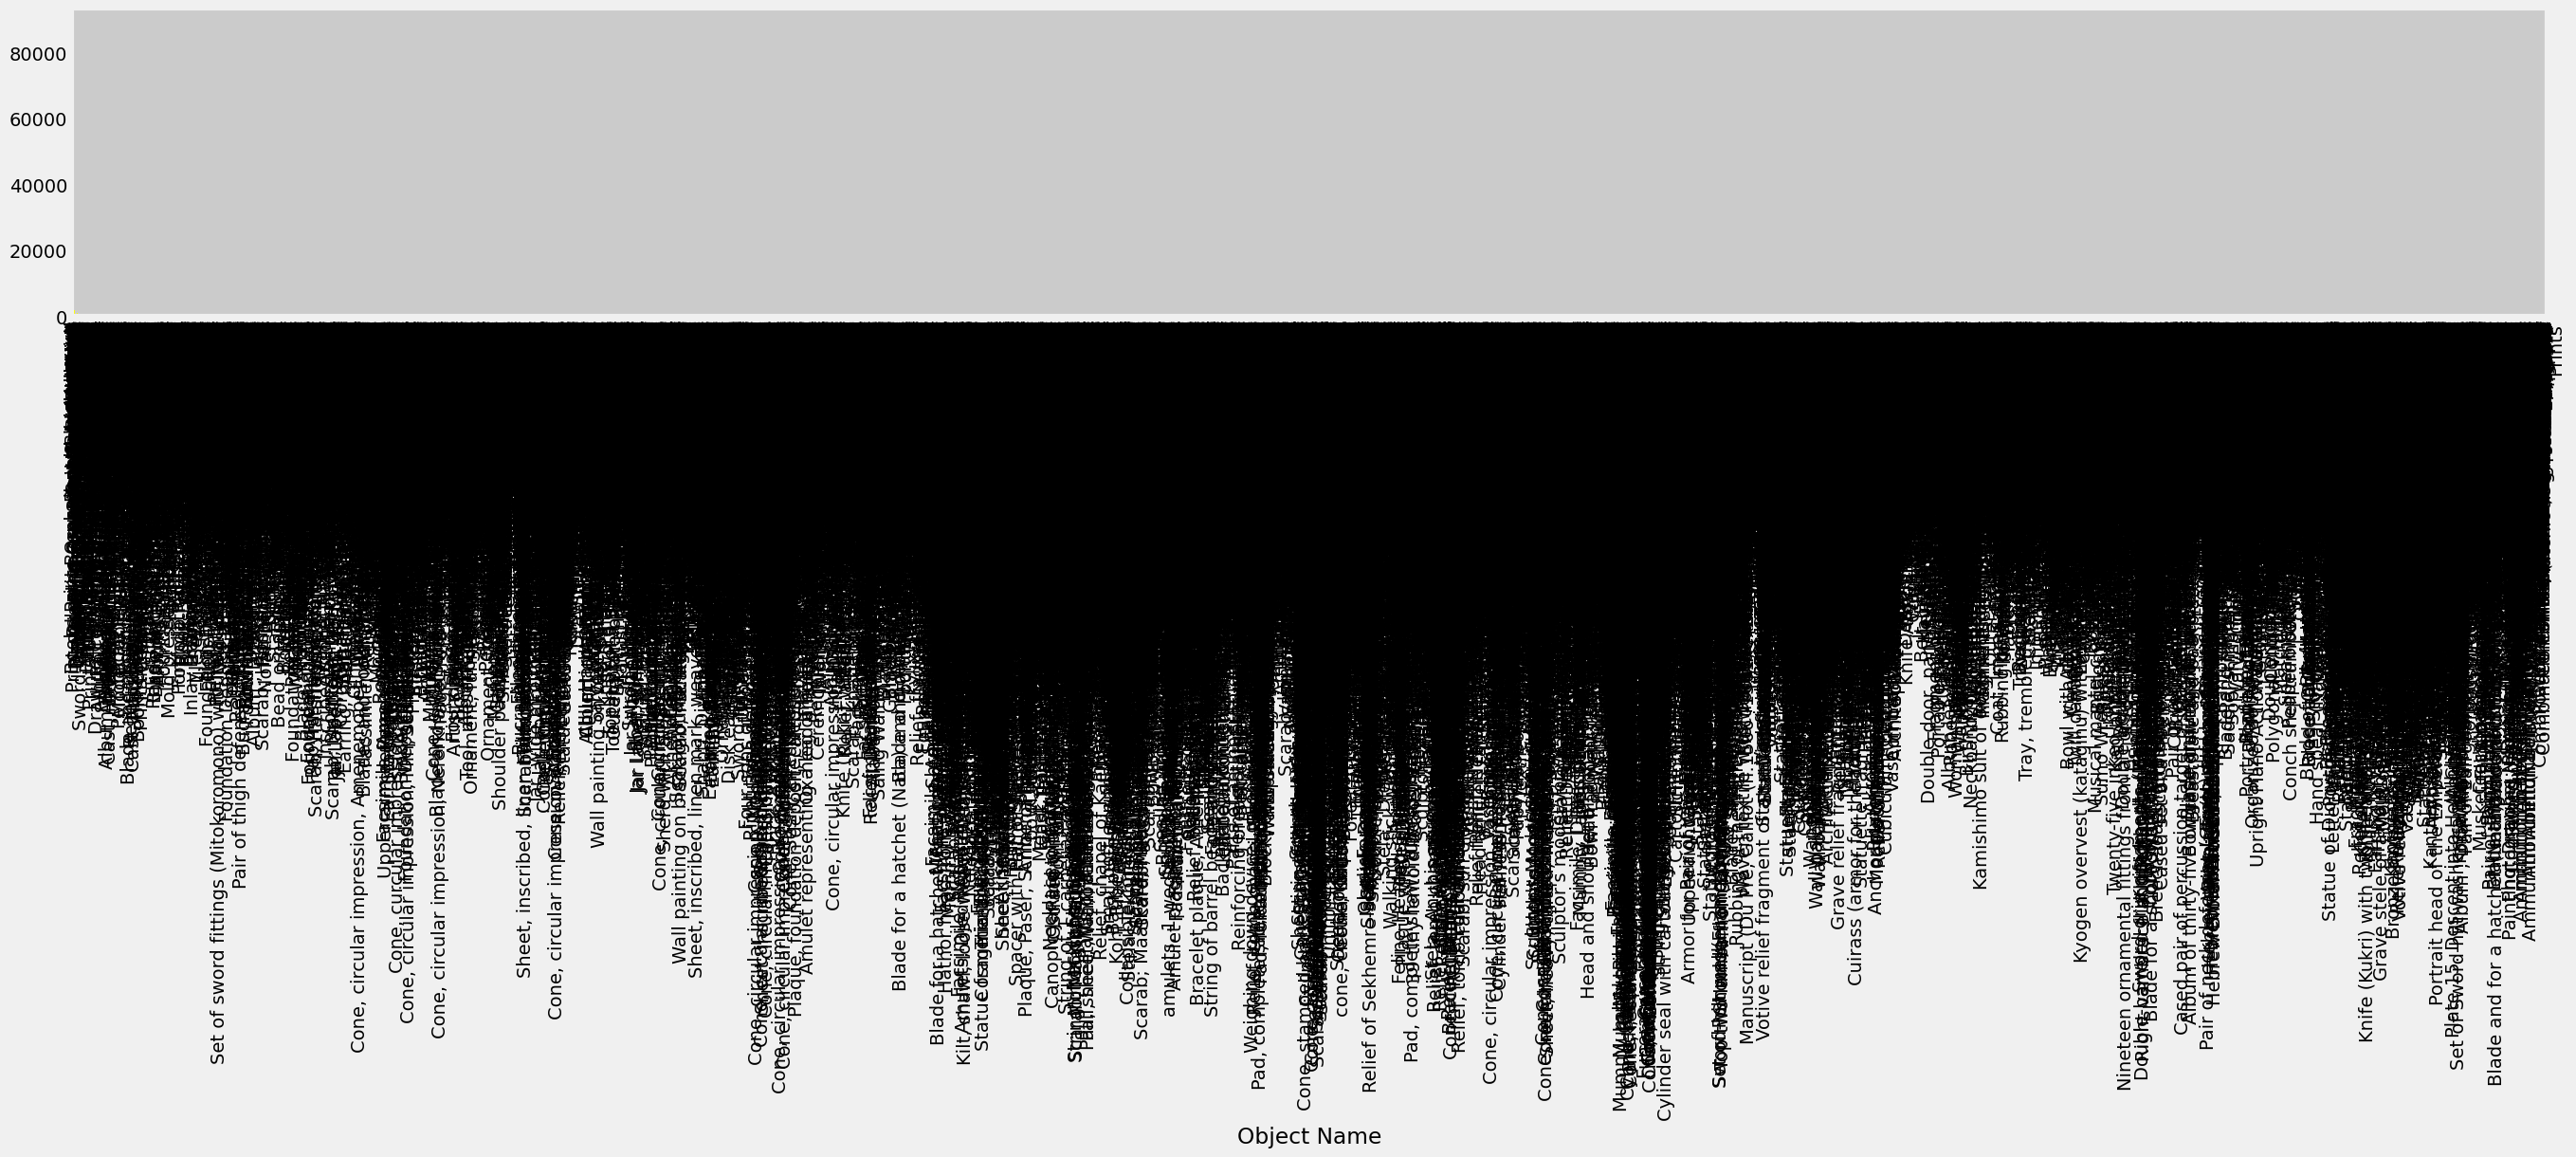

In [ ]:
dataset['Object Name'].value_counts().plot(kind='bar', figsize=(30, 4), color='yellow')

In [ ]:
dataset_cleaned['Object Name'].value_counts()[:10] , dataset['Object Name'].value_counts()[-10:]

(Object Name
 Print                   88972
 Photograph              28434
 Drawing                 24966
 Book                    13412
 Fragment                 9405
 Piece                    8634
 Negative                 6258
 Painting                 5887
 Baseball card, print     5208
 Bowl                     3535
 Name: count, dtype: int64,
 Object Name
 Mourning coif                 1
 Matchlock gun with bayonet    1
 Barkcloth                     1
 bow-harp                      1
 Cordophone                    1
 Model canoe                   1
 Female vessel                 1
 Ceremonial banner             1
 Money coil                    1
 Head wrapper                  1
 Name: count, dtype: int64)

In [ ]:
dataset_cleaned['Object Name'] = dataset['Object Name'].astype('category', errors='raise')

**Culture**

<Axes: xlabel='Culture'>

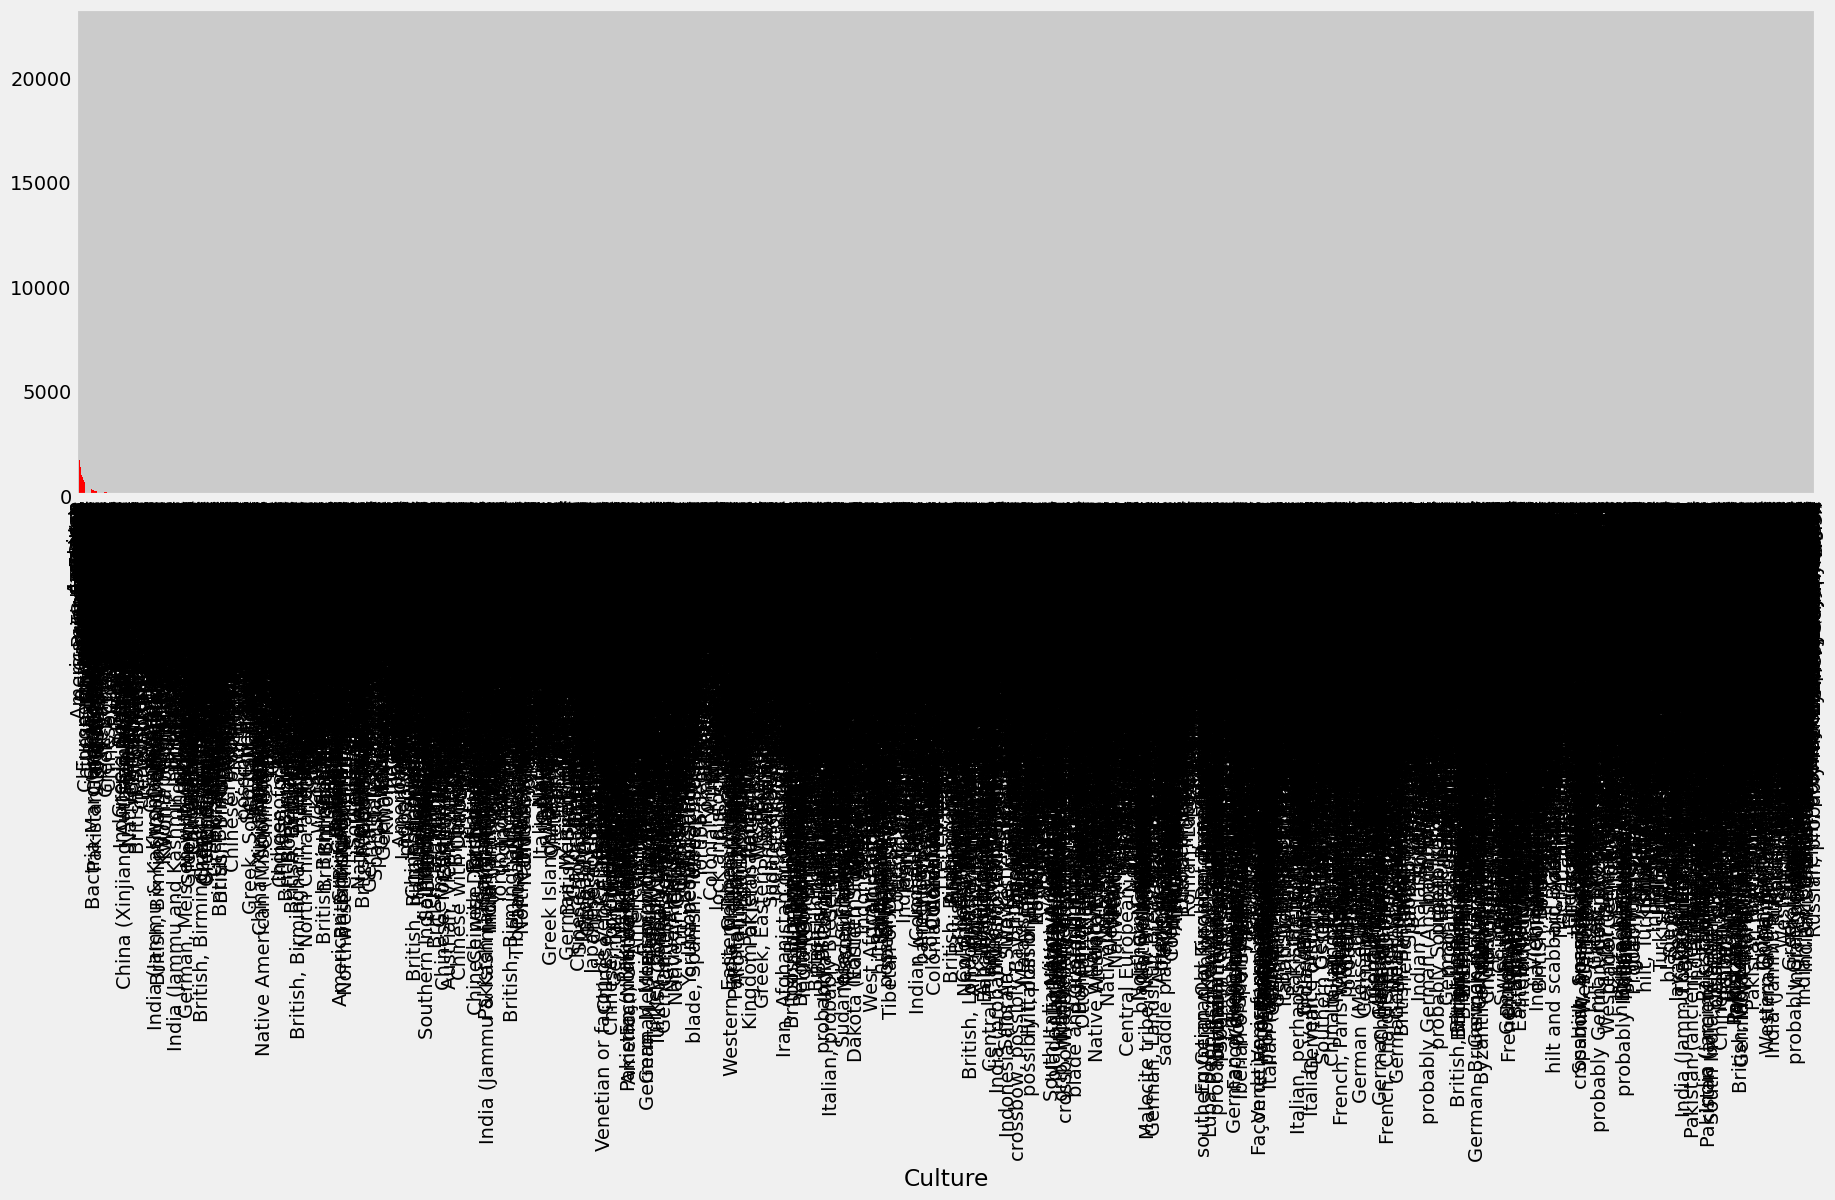

In [ ]:
dataset_cleaned['Culture'].value_counts().plot(kind='bar', figsize=(20, 6), color='red')

In [ ]:
dataset_cleaned['Culture'].value_counts()[:10] , dataset['Culture'].value_counts()[-10:]

(Culture
 American    22167
 French      18224
 Japan       16374
 China       13844
 Italian      6580
 Japanese     6044
 British      5310
 German       4798
 Roman        4790
 Cypriot      2921
 Name: count, dtype: int64,
 Culture
 Arts of Africa, Oceania, and the Americas    12427
 American Decorative Arts                     12330
 Medieval Art                                  7343
 Ancient Near Eastern Art                      6185
 American Paintings and Sculpture              5451
 Musical Instruments                           5303
 European Paintings                            2760
 The Cloisters                                 2628
 Robert Lehman Collection                      2589
 The Libraries                                  155
 Name: count, dtype: int64)

In [ ]:
dataset_cleaned['Culture'] = dataset['Culture'].astype('category', errors='raise')

**Period**

In [ ]:
dataset_cleaned['Period'].value_counts().plot(kind='bar', figsize=(20, 6), color='green')

<Axes: xlabel='Period'>

In [ ]:
for i in dataset_cleaned.dtypes:
    print(i)

object
bool
bool
int64
category
category
object
category
object
object
object
object
object
object
object
object
object
object
int64
int64
object
object
object
object
object
object
object
datetime64[ns]
object
int64
float64
float64
float64
object
object
